# Sentiment analysis of Spanish Amazon product reviews

## The problem

Marketplaces accumulate customer opinion faster than anyone can read it. The star rating is easy
to aggregate but only says *how* satisfied a customer was; the text says *why*, and it is the
part that does not scale. This project asks whether the sentiment can be recovered from the text
alone, and whether the corpus can then be queried in natural language.

## The data

[Amazon Reviews Multi](https://www.kaggle.com/datasets/mexwell/amazon-reviews-multi), shipped as
three files (`train`, `validation`, `test`) covering six languages. **Only the Spanish reviews
are used**: 210,000 of them.

| Column | Content |
|---|---|
| `review_body` | Free text of the review |
| `review_title` | Title written by the customer |
| `stars` | Rating from 1 to 5, from which the target label is derived |
| `product_category` | Product category, e.g. `electronics`, `home`, `apparel` |
| `product_id`, `reviewer_id` | Anonymised identifiers |
| `review_id`, `language` | Review identifier and language code |

The rating is grouped into **three sentiment classes**:

| Sentiment | Stars |
|---|---|
| Negative | 1, 2 |
| Neutral | 3 |
| Positive | 4, 5 |

Predicting the exact star level is deliberately not the goal: the difference between 4 and 5
stars reflects each customer's personal scale more than anything the review says. The neutral
class is kept rather than discarded, since a lukewarm opinion is a real outcome.

## Objectives

**Sentiment classification.** Predict whether a review is negative, neutral or positive from its
text alone.

**Retrieval-augmented question answering (RAG).** Answer questions about the corpus by retrieving
the relevant reviews and grounding the answer in them.

## Why it is useful

- Sentiment scoring extends to any customer text with no rating attached: support tickets,
  survey responses, social media mentions.
- A product whose incoming reviews turn negative can be flagged before its star average moves.
- Retrieval turns *what do customers complain about in this category?* into a query rather than a
  week of manual reading.

## Methodology

Each stage is measured against the previous one, so that added complexity has to justify itself.

1. **Data quality and exploratory analysis.** What the corpus contains and whether it is fit for
   the objectives above.
2. **Category-level analysis.** Which categories concentrate the best and worst opinions, and how
   sentiment relates to length and writing style, supported by statistical tests.
3. **Baseline.** Bag-of-words with a linear classifier: fast, interpretable, and the floor that
   anything more sophisticated must beat.
4. **Pretrained language model.** A transformer pretrained on Spanish, fine-tuned on this corpus,
   which unlike the baseline can use word order and context.
5. **Formal comparison.** Both models on the same held-out data: macro and per-class F1, accuracy,
   confusion matrices and inference time. The classes are unevenly represented once grouped, so
   macro F1 is the headline metric, and a model that is marginally better but far slower is not
   automatically the right choice.
6. **Embedding visualisation.** Two-dimensional projections to see whether the three classes
   separate, and where they overlap.
7. **Retrieval system.** A vector database over the reviews, answering questions grounded in the
   retrieved text.

## Scope of this notebook

Stage 1: loading, filtering, quality assessment, cleaning and exploratory analysis.


# Libraries

In [5]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import emoji
import time
# NLTK 3.10.1 refuses to import any dependency that resolves to a path inside the
# current working directory. The virtual environment lives in ./.venv, so every
# NLTK dependency in site-packages is flagged as untrusted and the import fails.
# Loading them here, before NLTK itself, keeps that check from triggering.
import regex, defusedxml.ElementTree, joblib, tqdm, click

import nltk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from nltk.corpus import stopwords
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import chi2_contingency

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay


import torch
import torch.nn as nn
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)


from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import cohen_kappa_score



# Reproducibility

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO DISPONIBLE')

GPU: NO DISPONIBLE


# Data

The dataset ships as three files, `train.csv`, `validation.csv` and `test.csv`, already
partitioned by its authors.

**The three are merged into a single DataFrame**, because exploratory analysis describes a
corpus: every quality check would otherwise be repeated three times, conditioned on a partition
unrelated to the phenomenon being studied.

**A `split` column is added before merging**, recording each row's file of origin. That is what
makes the merge reversible: the authors' partition, which exists so results are comparable
across studies, is preserved inside the data.

Each file covers six languages. Only Spanish is kept.


In [7]:
path = kagglehub.dataset_download("mexwell/amazon-reviews-multi")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/mexwell/amazon-reviews-multi/versions/1


In [8]:
train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")
validation = pd.read_csv(f"{path}/validation.csv")

train['split'] = 'train'
test['split'] = 'test'
validation['split'] = 'validation'

In [9]:
df = pd.concat([train, test, validation], ignore_index=True)

df.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports,train
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement,train
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore,train
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore,train
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy,train


# Data exploration

The corpus is filtered to Spanish and saved before anything else, so the raw subset is always
recoverable. The checks that follow are the basics: size, column types, missing values,
duplicated rows, and how the reviews distribute across the three original files. Nothing is
modified at this stage except the removal of the residual index column.


In [10]:
df_spanish = df[df['language'] == 'es'].copy()

df_spanish.to_csv('amazon_reviews_spanish.csv', index=False)

In [11]:
df_spanish.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


In [12]:
df_spanish.tail()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
1244995,14995,es_0179515,product_es_0158275,reviewer_es_0273644,5,Me ha encantado la cesta. Ha llegado impecable...,guadalupe,es,home,validation
1244996,14996,es_0894902,product_es_0953259,reviewer_es_0153773,5,Desempeña su función correctamente,calidad precio,es,camera,validation
1244997,14997,es_0760496,product_es_0731995,reviewer_es_0171091,5,Me ha encantado la diadema! Las flores son tal...,Excelente,es,toy,validation
1244998,14998,es_0178380,product_es_0402051,reviewer_es_0686937,5,"A mi me gustan mucho las fundas TPU, ya que so...",Genial,es,wireless,validation
1244999,14999,es_0810087,product_es_0684221,reviewer_es_0613091,5,El artículo ha cumplido con las expectativas q...,Buena calidad,es,apparel,validation


In [13]:
df_spanish.info()

<class 'pandas.DataFrame'>
Index: 210000 entries, 400000 to 1244999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Unnamed: 0        210000 non-null  int64
 1   review_id         210000 non-null  str  
 2   product_id        210000 non-null  str  
 3   reviewer_id       210000 non-null  str  
 4   stars             210000 non-null  int64
 5   review_body       210000 non-null  str  
 6   review_title      210000 non-null  str  
 7   language          210000 non-null  str  
 8   product_category  210000 non-null  str  
 9   split             210000 non-null  str  
dtypes: int64(2), str(8)
memory usage: 64.9 MB


In [14]:
df_spanish.describe()

,Unnamed: 0,stars
count,210000.000000,210000.000000
mean,476785.214286,3.000000
std,118122.098049,1.414217
min,10000.000000,1.000000
25%,442499.750000,2.000000
50%,494999.500000,3.000000
75%,547499.250000,4.000000
max,599999.000000,5.000000


In [15]:
df_spanish['split'].value_counts()

split
train         200000
test            5000
validation      5000
Name: count, dtype: int64

In [16]:
df_spanish.isnull().mean() * 100

Unnamed: 0          0.0
review_id           0.0
product_id          0.0
reviewer_id         0.0
stars               0.0
review_body         0.0
review_title        0.0
language            0.0
product_category    0.0
split               0.0
dtype: float64

In [17]:
df_spanish.duplicated().sum()

np.int64(0)

The checks above modify nothing. The only change made in this section is dropping
`Unnamed: 0`, whose values were just shown to be a residual index carrying no information.


In [18]:
df_spanish = df_spanish.drop(columns=['Unnamed: 0'])

In [19]:
df_spanish.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


### Structural inspection: findings

- The Spanish subset contains **210,000 reviews**, distributed as 200,000 / 5,000 / 5,000
  across the three original files.
- **No missing values** in any column, and **no fully duplicated rows**.
- `Unnamed: 0` is a residual index inherited from the source CSVs. Its values range from
  10,000 to 599,999 and overlap across files, so it identifies nothing and is dropped.
- The `language` column is constant (`es`) after filtering. It is kept only for traceability.


## Stars distribution

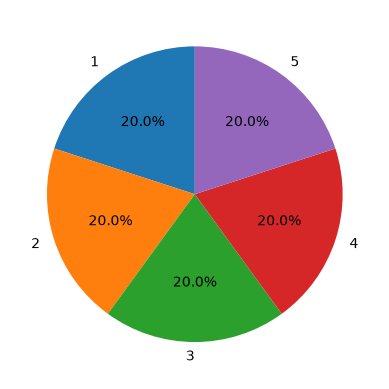

In [20]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

# Create Target Variable

The five rating levels are the raw label, but the target of this project is the three-way
sentiment class defined in the introduction. The `sentiment` column derives it from `stars`
through an explicit mapping, so the correspondence is visible in the code rather than hidden
in a condition. The second pie chart shows what the grouping does to the class proportions.


In [21]:
SENTIMENT = {1: 'negative', 2: 'negative', 3: 'neutral', 4: 'positive', 5: 'positive'}

df_spanish['sentiment'] = df_spanish['stars'].map(SENTIMENT)

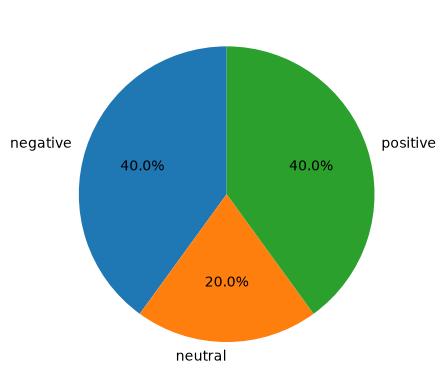

In [22]:
sentiments = df_spanish['sentiment']
counts = sentiments.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

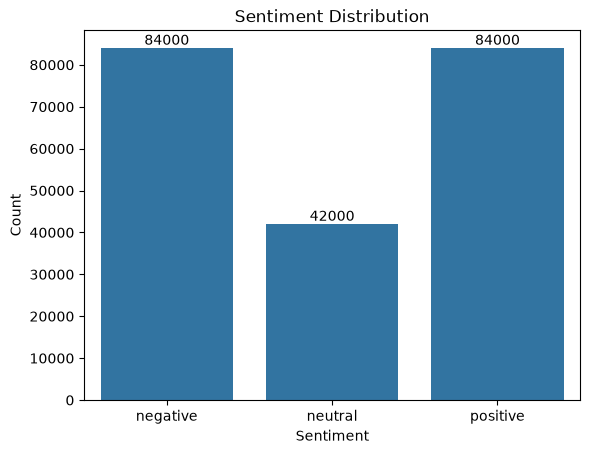

In [23]:
ax=sns.barplot(data=counts)
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()



The five rating levels are **perfectly balanced**, 20 % each, with a mean of exactly 3.000.

This balance is **artificial**, built into the corpus by design. Real Amazon ratings skew heavily
towards 5 stars, so any claim about "the proportion of dissatisfied customers" would be invalid
here. What the balance does allow is a clean comparison of the language used at each level.

**It does not survive the grouping into sentiment classes.** Mapping 1-2, 3 and 4-5 gives
84,000 / 42,000 / 84,000, a 2:1:2 proportion. Two consequences:

- **Accuracy stops being a safe headline metric.** A model that never predicts neutral would
  still be right about 80 % of the time. Macro and per-class F1 expose that failure mode.
- **Reweighting the neutral class becomes a real decision**, where on the five-level scale it
  would have been unnecessary.


# Text analysis

Cleaning is applied to **copies** of the text, never to the original columns.

| Column | Content |
|---|---|
| `review_body`, `review_title` | Original text, never modified |
| `body_clean`, `title_clean` | Normalised text, used for the analysis below |

Keeping the originals lets every step be verified side by side, allows other variants to be
derived later, and preserves the reviews as the customer wrote them for any use that needs to
display them.

Each diagnostic follows the same procedure: build a mask, measure how many reviews are affected,
read a sample, and only then decide on a rule. A transformation that fixes a problem the corpus
does not have adds risk without adding value.

**Every artefact found here is resolved by dropping the affected rows**, for three reasons:

- **The counts are small.** No artefact reaches 0.4 % of the corpus, so removal cannot shift any
  distribution or metric.
- **Dropping avoids introducing artificial text.** Rewriting an artefact inserts strings no
  customer wrote, rare and concentrated in specific reviews, which is the shape of a spurious
  feature a model can latch onto.
- **What remains is more than enough.** Over 208,000 reviews survive; nothing here is limited by
  sample size.


## Emojis

Emojis are detected with `emoji.emoji_count`, which works from the official Unicode emoji
table rather than from a hand-written character range, so compound emojis and skin-tone
modifiers are counted correctly. Prevalence is measured separately on the body and the title,
a sample of the matches is read before any decision is taken, and the conversion is verified
afterwards by running the same count again on the cleaned columns.


In [24]:
mask_emoji = df_spanish['review_body'].apply(emoji.emoji_count) > 0
mask_emoji_title = df_spanish['review_title'].apply(emoji.emoji_count) > 0


In [25]:
df_spanish[mask_emoji][['review_body']].sample(10, random_state=seed)

,review_body
599557,Hermética!! Va muy muy bien y es súper bonita 😜
407040,👎🏻 no sé gana nada d peso
447393,"Pierde muy rápido el Bluetooth, se desparejan ..."
443705,Me es difícil escribir una opinión de este pro...
453321,"Son grandes, sobre todo demasiado anchas. Una ..."
448466,Los cuencos muy pequeños para el tamaño de mi ...
554558,"Pedí uno para mí mujer y vino defectuoso, meno..."
569087,"Muy bueno y bonito, pero el primer día la prof..."
472742,Menos de un mes de uso y ya empieza a desinteg...
429166,"Es de plástico y muy fina, es igual que no pon..."


In [26]:
df_spanish[mask_emoji_title][['review_title']].sample(10, random_state=seed)

,review_title
504214,Champú.. 🤷‍♂️
1212217,"Bien para música, llamadas ☹️"
591260,Perfecto 👌🏼
559890,👌🏻
503790,☹️
574774,Correcto 👍🏼
586313,Compra 💯%
555074,Buena..😁
575338,Bonitas 👍🏻
528987,👌🏻


In [27]:
print("Number of reviews with emojis in the body:", mask_emoji.sum())
print("Number of reviews with emojis in the title:", mask_emoji_title.sum())

Number of reviews with emojis in the body: 786
Number of reviews with emojis in the title: 351


In [28]:
print(f"Number of reviews with emojis in the body: {mask_emoji.mean()*100:.2f}%")
print(f"Number of reviews with emojis in the title: {mask_emoji_title.mean()*100:.2f}%")

Number of reviews with emojis in the body: 0.37%
Number of reviews with emojis in the title: 0.17%


Measurement ends here and the rows carrying the artefact are removed. The mask covers the
body and the title, so a review is dropped if either field contains an emoji.


In [29]:
df_spanish = df_spanish[~mask_emoji & ~mask_emoji_title].copy()

### Emojis: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing emojis | 786 (0.37 %) | 351 (0.17 %) |

**Decision: drop the affected rows.** A review is removed if an emoji appears in either field,
which takes out 1,098 rows, 0.52 % of the corpus.

Converting the characters to their written description was considered, and the `emoji` library
does it reliably. It was rejected because an alias such as `:cara_llorando_de_risa:` is not
Spanish: it is a rare token tied to whichever ratings those reviews happen to carry, which is the
classic shape of a shortcut feature. Keeping it would also mean maintaining a conversion step and
the decisions hanging off it, such as skin-tone modifiers, for half a percent of the data.


## URLs

In [30]:
URL_PATTERN = r"(?i)\b(?:https?://|www\.)\S+"


mask_url_body = df_spanish['review_body'].str.contains(URL_PATTERN, regex=True)
mask_url_title = df_spanish['review_title'].str.contains(URL_PATTERN, regex=True)

In [31]:
print(f"Number of reviews with URLs in the body: {mask_url_body.sum()}")
print(f"Number of reviews with URLs in the title: {mask_url_title.sum()}")

Number of reviews with URLs in the body: 1
Number of reviews with URLs in the title: 0


In [32]:
df_spanish = df_spanish[~mask_url_body & ~mask_url_title].copy()

In [33]:
df_spanish.shape

(208901, 10)

### URLs: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing URLs | 1 | 0 |

**Decision: drop the affected row.**

One occurrence is a negligible quantity: removing it cannot affect any result. Writing a
substitution rule for a single case would add permanent code to the pipeline in exchange for
nothing, so the row is dropped, in line with the criterion set out above.


## Email addresses

In [34]:
EMAIL_PATTERN = r"(?i)\b[\w-]+@[\w-]+\.(?:com|es|net|org|info|io|store|online)\b"

mask_email_body = df_spanish['review_body'].str.contains(EMAIL_PATTERN, regex=True)
mask_email_title = df_spanish['review_title'].str.contains(EMAIL_PATTERN, regex=True)

In [35]:
print(f"Number of reviews with emails in the body: {mask_email_body.sum()}")
print(f"Number of reviews with emails in the title: {mask_email_title.sum()}")

Number of reviews with emails in the body: 0
Number of reviews with emails in the title: 0


### Email addresses: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing email addresses | 0 | 0 |

**Decision: no treatment required.** The phenomenon does not occur in this corpus. This also
means the dataset carries no personal contact details in its free text.


## HTML

In [36]:
HTML_TAG_PATTERN = r"<[^>]+>"
HTML_ENTITY_PATTERN = r"&[a-zA-Z]+;|&#\d+;"

mask_html_tag_body = df_spanish['review_body'].str.contains(HTML_TAG_PATTERN, regex=True)
mask_html_tag_title = df_spanish['review_title'].str.contains(HTML_TAG_PATTERN, regex=True)

mask_html_ent_body = df_spanish['review_body'].str.contains(HTML_ENTITY_PATTERN, regex=True)
mask_html_ent_title = df_spanish['review_title'].str.contains(HTML_ENTITY_PATTERN, regex=True)

print(f"Number of reviews with HTML tags in the body: {mask_html_tag_body.sum()}")
print(f"Number of reviews with HTML tags in the title: {mask_html_tag_title.sum()}")
print(f"Number of reviews with HTML entities in the body: {mask_html_ent_body.sum()}")
print(f"Number of reviews with HTML entities in the title: {mask_html_ent_title.sum()}")


Number of reviews with HTML tags in the body: 2
Number of reviews with HTML tags in the title: 0
Number of reviews with HTML entities in the body: 0
Number of reviews with HTML entities in the title: 0


In [37]:
df_spanish = df_spanish[~mask_html_tag_body & ~mask_html_tag_title & ~mask_html_ent_body & ~mask_html_ent_title].copy()


In [38]:
df_spanish.shape

(208899, 10)

### HTML: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| HTML tags | 2 | 0 |
| HTML entities | 0 | 0 |

**Decision: drop the affected rows.**

Markup such as `<br />` and `&amp;` is common in scraped review corpora, so its near-absence is
worth stating: this dataset was sanitised before publication and needs no HTML-stripping stage.

This closes the removals. The corpus goes from 210,000 reviews to **208,899**: 1,098 dropped for
emojis, 2 for HTML and 1 for a URL, or 0.52 % of the original.


## Whitespace

In [39]:

df_spanish['body_clean'] = (
    df_spanish['review_body'].str.replace(r"\s+", " ", regex=True).str.strip()
)
df_spanish['title_clean'] = (
    df_spanish['review_title'].str.replace(r"\s+", " ", regex=True).str.strip()
)



### Whitespace: findings and decision

No anomalous whitespace (repeated, leading or trailing spaces) was found in the original columns.

**Decision: apply the normalisation anyway.** Collapsing `\s+` to a single space and trimming the
ends costs nothing, and it is the one transformation that cannot introduce anything artificial:
it removes redundant separators, never adds or rewrites a character. It is also what defines
`body_clean` and `title_clean`.

In Python 3, `\s` already covers non-breaking and typographic spaces as well as tabs and line
breaks. The zero-width space (`\u200b`) is the one exception and would need its own check.


## Post-cleaning check

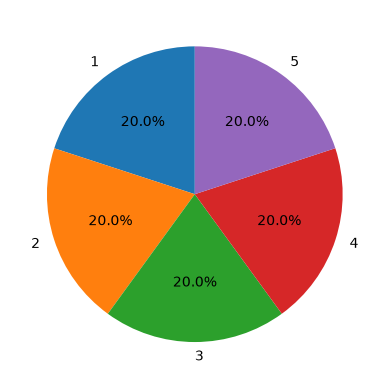

In [40]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

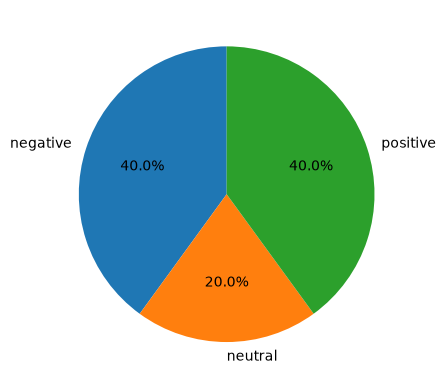

In [41]:
sentiments = df_spanish['sentiment']
counts = sentiments.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

In [42]:
stars.value_counts().sort_index()

stars
1    41727
2    41818
3    41828
4    41818
5    41708
Name: count, dtype: int64

In [43]:
sentiments.value_counts().sort_index()

sentiment
negative    83545
neutral     41828
positive    83526
Name: count, dtype: int64

In [44]:
df_spanish['body_clean'].sample(10, random_state=seed)

570590     Cuando lo vi no dude en comprarlo,me parece qu...
420162     Llega en mal estado las piezas. El montaje es ...
499206          El dvd está bien pero vino con la caja rota.
426599     la correa no se acopla bien al reloj, encima m...
500307     Como tostadora de pan, el pan queda espectacul...
416966     LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...
1241321        Dura igual que la antigua, se descarga rapido
566100     Buen precio. Plazo largo pero para tener en el...
562575      Perfecto envuelto, caja en perfectas condiciones
440281     Tardan en calentarse y se pegan. Cierto es que...
Name: body_clean, dtype: str

In [45]:
df_spanish['title_clean'].sample(10, random_state=seed)

570590         Lo compré como complemento de la granja
420162          Revisión de las piezas antes del envio
499206                           Vino con la caja rota
426599                                            MALA
500307     Lo uso exclusivamente como tostadora de pan
416966                                  NO ENCIENDE...
1241321                 Barata pero se descarga rapido
566100                        Precio bueno plazo largo
562575                                    Envio rápido
440281                 No son tan buenas como parecian
Name: title_clean, dtype: str

### After cleaning: verification

**The distribution survives.** The five rating levels end between 41,708 and 41,828 reviews, a
spread of 0.3 %, and the sentiment classes stand at 83,545 / 41,828 / 83,526. The 2:1:2
proportion is intact.

This was worth checking rather than assuming: emojis are not used evenly across rating levels, so
dropping every review containing one could have thinned a class more than the others. It did not.

The sampled text is natural Spanish, identical to the original wording. Nothing was rewritten,
only whitespace normalised, and every review carrying an artefact was removed rather than
repaired.


The cleaned dataset is written to disk here. From this point on, later work can start from
`amazon_reviews_spanish_cleaned.csv` instead of re-running the download, the filtering and the
cleaning. The file keeps the original text columns alongside the cleaned ones and the derived
`sentiment` label.


In [46]:
df_spanish.to_csv('amazon_reviews_spanish_cleaned.csv', index=False)

# Text length and word frequency

Length is measured in characters on the cleaned columns, since those are the ones the rest of
the analysis uses. Each field is first summarised numerically and then shown twice: a boxplot,
which makes the spread and the outliers visible, and a histogram, which shows the shape of the
distribution. Body and title are treated separately because they are different kinds of text.


In [47]:
text_lengths = df_spanish['body_clean'].str.len()

In [48]:
text_lengths.describe()

count    208899.000000
mean        151.316440
std         132.143112
min          16.000000
25%          68.000000
50%         120.000000
75%         186.000000
max        3086.000000
Name: body_clean, dtype: float64

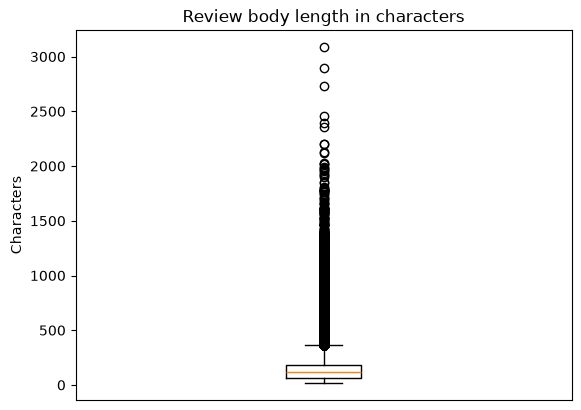

In [49]:
plt.boxplot(text_lengths)
plt.title('Review body length in characters')
plt.ylabel('Characters')
plt.xticks([])
plt.show()


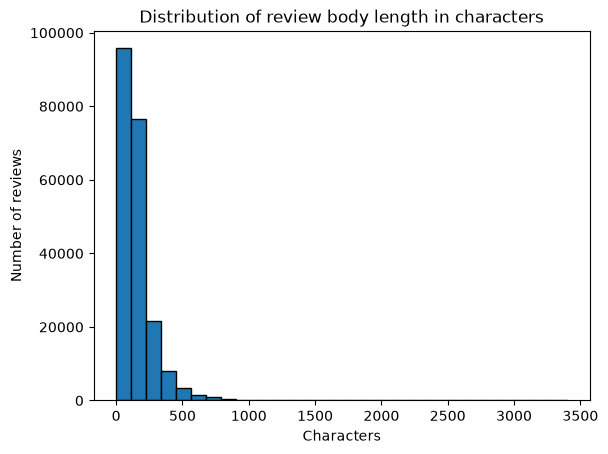

In [50]:
plt.hist(text_lengths, bins=30, edgecolor='black', range=(0, 3400))
plt.title('Distribution of review body length in characters')
plt.xlabel('Characters')
plt.ylabel('Number of reviews')
plt.show()


In [51]:
title_length = df_spanish['title_clean'].str.len()

In [52]:
title_length.describe()

count    208899.000000
mean         19.181987
std          13.422380
min           1.000000
25%          10.000000
50%          16.000000
75%          25.000000
max         128.000000
Name: title_clean, dtype: float64

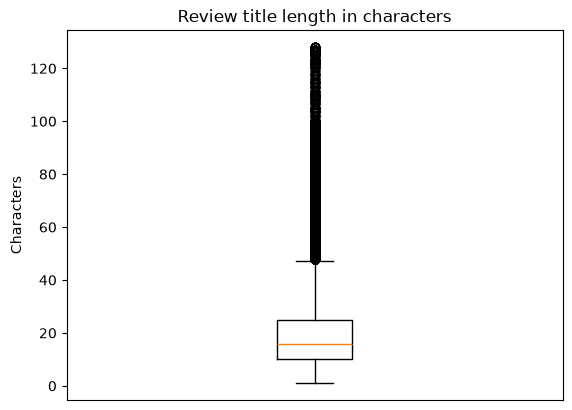

In [53]:
plt.boxplot(title_length)
plt.title('Review title length in characters')
plt.ylabel('Characters')
plt.xticks([])
plt.show()


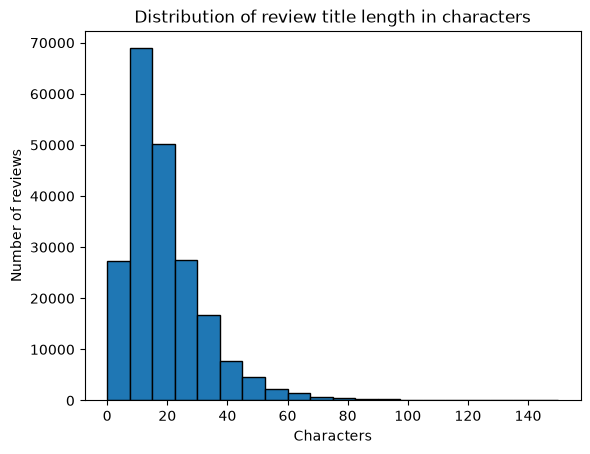

In [54]:
plt.hist(title_length, bins=20, edgecolor='black', range=(0, 150))
plt.title('Distribution of review title length in characters')
plt.xlabel('Characters')
plt.ylabel('Number of reviews')
plt.show()


### Text length: findings

| | `body_clean` | `title_clean` |
|---|---|---|
| Mean | 151.3 | 19.2 |
| Median | 120 | 16 |
| 25th percentile | 68 | 10 |
| 75th percentile | 186 | 25 |
| Maximum | 3,086 | 128 |
| Minimum | 16 | 1 |

**These are short texts.** A median of 120 characters is about twenty words, two sentences. A
quarter of all reviews fit in 68 characters. Titles are shorter still, a median of 16 characters
and closer to a label than a sentence: *Excelente*, *Devuelto*, *Buena calidad*.

Both distributions are strongly right-skewed, with a thin tail reaching 3,086 characters. The
boxplot outliers are legitimate detailed reviews, not corrupted records.

Customers here write brief, direct verdicts rather than reasoned essays. There is little room in
120 characters for nuance, so whatever signal exists is concentrated in a handful of words.


Word frequencies are computed on the cleaned columns, lowercased at analysis time rather than
stored in lowercase, since capitalisation is itself a feature worth keeping in the data. The
token pattern accepts sequences of two or more Spanish letters, which discards punctuation and
digits without needing a separate cleaning rule.


In [55]:
nltk.download('stopwords')

# Negations and adversatives are on the standard Spanish stopword list, but they carry
# the polarity of the sentence, so they are kept.
NEGATIONS = {'no', 'ni', 'nunca', 'nada', 'sin', 'pero', 'tampoco', 'jamás'}
STOPWORDS_ES = set(stopwords.words('spanish')) - NEGATIONS

TOKEN_PATTERN = r"[a-záéíóúüñ]{2,}"


def top_words(series, n=10):
    words = series.str.lower().str.findall(TOKEN_PATTERN).explode()
    return words[~words.isin(STOPWORDS_ES)].value_counts().head(n)


print(top_words(df_spanish['body_clean']))
print(top_words(df_spanish['title_clean']))


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alejandro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


body_clean
no          162312
pero         67785
bien         53921
calidad      33415
si           26294
producto     25745
precio       24063
buena        20306
nada         16890
sin          16876
Name: count, dtype: int64
title_clean
no          31844
calidad     16371
bien        12456
buena       10455
precio       9016
buen         7960
pero         7797
producto     7744
mal          4599
perfecto     4404
Name: count, dtype: int64


### Most frequent words: findings

Computed on the cleaned columns after lowercasing, tokenising and removing Spanish stopwords.

**The stopword list was filtered before use.** The standard NLTK Spanish list includes `no`,
`ni`, `nunca`, `nada`, `sin` and `pero`. In the unfiltered count `pero` appears 67,785 times,
`nada` 16,890 and `sin` 16,876. These are not filler here: `nada` reverses the meaning of what
follows, `sin` marks something the product lacks, and `pero` introduces the clause carrying the
verdict. Removing them would erase over 100,000 occurrences of the most informative tokens.

Evaluative terms such as *bien*, *calidad*, *precio*, *buena* and *perfecto* rank high, with the
two recurring themes being quality and price. The vocabulary is concentrated rather than diffuse.

One limitation: counting single words cannot separate "funciona perfectamente" from "no
funciona". Frequency counts describe what customers talk about, not what they conclude.


## Number of words

Characters measure how much text there is; words measure how much the customer said, and words
are the unit both modelling approaches operate on.

The purpose is not only descriptive. Filtering out very short reviews is a routine step in text
pipelines, on the assumption that they carry too little signal. Whether that holds here is an
empirical question, so the extremes of both fields are read directly.


In [56]:
n_words = df_spanish['body_clean'].apply(lambda x: len(x.split()))
n_words.head(5)

400000    19
400001    23
400002    22
400003    60
400004     7
Name: body_clean, dtype: int64

In [57]:
n_words.describe()

count    208899.000000
mean         27.796294
std          24.160655
min           2.000000
25%          13.000000
50%          22.000000
75%          34.000000
max         551.000000
Name: body_clean, dtype: float64

In [58]:
df_copy = df_spanish.copy()
df_copy['n_words'] = n_words

df_copy.sort_values(by='n_words', ascending=False).head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
592038,es_0510677,product_es_0589578,reviewer_es_0596584,5,"Hago estos cambios en mi opinión, no por el pr...","El mejor que he tenido, y he tenido muchos... ...",es,other,train,positive,"Hago estos cambios en mi opinión, no por el pr...","El mejor que he tenido, y he tenido muchos... ...",551
469098,es_0009626,product_es_0148157,reviewer_es_0673664,2,Compré esta depiladora recomendada por una ami...,"Resultados regulares, sensor muy mejorable",es,personal_care_appliances,train,negative,Compré esta depiladora recomendada por una ami...,"Resultados regulares, sensor muy mejorable",506
444542,es_0630958,product_es_0681215,reviewer_es_0117745,2,La idea de este producto está bastante bien: m...,Aunque cumple su proposito no me convence del ...,es,sports,train,negative,La idea de este producto está bastante bien: m...,Aunque cumple su proposito no me convence del ...,474
508629,es_0274560,product_es_0488105,reviewer_es_0267835,3,"La linterna funciona muy bien, en términos gen...","Sensor de movimiento out. Por lo demás, buena ...",es,sports,train,neutral,"La linterna funciona muy bien, en términos gen...","Sensor de movimiento out. Por lo demás, buena ...",458
576581,es_0624792,product_es_0448801,reviewer_es_0814793,5,La idea era comprar un radio reloj despertador...,Radio BT Funcional y Económica,es,wireless,train,positive,La idea era comprar un radio reloj despertador...,Radio BT Funcional y Económica,430


In [59]:
df_copy.sort_values(by='n_words', ascending=False).tail()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
511847,es_0824406,product_es_0483816,reviewer_es_0849668,3,Producto maravilloso,El artículo está bien,es,personal_care_appliances,train,neutral,Producto maravilloso,El artículo está bien,2
574980,es_0375288,product_es_0764903,reviewer_es_0932454,5,Funcionamiento oerfecto,Funcionamiento perfecto,es,home,train,positive,Funcionamiento oerfecto,Funcionamiento perfecto,2
440198,es_0466351,product_es_0376291,reviewer_es_0996750,2,Cogen interferencias,Interferencia,es,musical_instruments,train,negative,Cogen interferencias,Interferencia,2
514675,es_0298854,product_es_0061954,reviewer_es_0015919,3,Relación calidad/precio,Rapidez y comodidad,es,shoes,train,neutral,Relación calidad/precio,Rapidez y comodidad,2
1213749,es_0453309,product_es_0357221,reviewer_es_0544111,4,Descripción correcta.,Descripción correcta.,es,camera,test,positive,Descripción correcta.,Descripción correcta.,2


In [60]:
df_copy.sample(10, random_state=seed)

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
570590,es_0231757,product_es_0182754,reviewer_es_0195405,5,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,es,toy,train,positive,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,35
420162,es_0150762,product_es_0354483,reviewer_es_0923957,1,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,es,furniture,train,negative,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,23
499206,es_0457292,product_es_0106439,reviewer_es_0593901,3,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,es,other,train,neutral,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,10
426599,es_0529522,product_es_0460980,reviewer_es_0850227,1,"la correa no se acopla bien al reloj, encima m...",MALA,es,sports,train,negative,"la correa no se acopla bien al reloj, encima m...",MALA,27
500307,es_0613906,product_es_0487562,reviewer_es_0012782,3,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,es,kitchen,train,neutral,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,50
416966,es_0073956,product_es_0612354,reviewer_es_0326739,1,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,es,camera,train,negative,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,20
1241321,es_0571648,product_es_0621858,reviewer_es_0645188,2,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,es,electronics,validation,negative,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,8
566100,es_0428859,product_es_0223040,reviewer_es_0468724,5,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,es,wireless,train,positive,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,18
562575,es_0939408,product_es_0388291,reviewer_es_0688865,5,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,es,toy,train,positive,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,6
440281,es_0142231,product_es_0858186,reviewer_es_0357303,2,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,es,home,train,negative,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,22


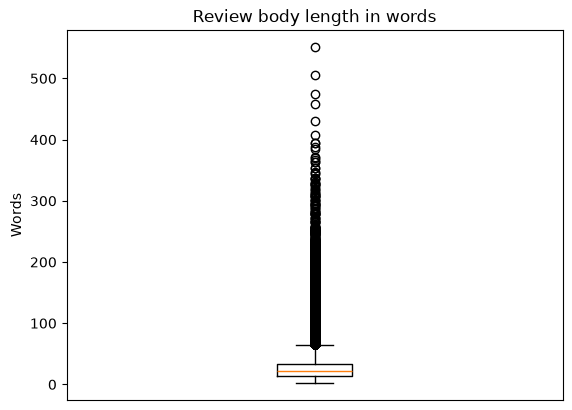

In [61]:
plt.boxplot(n_words)
plt.title('Review body length in words')
plt.ylabel('Words')
plt.xticks([])
plt.show()


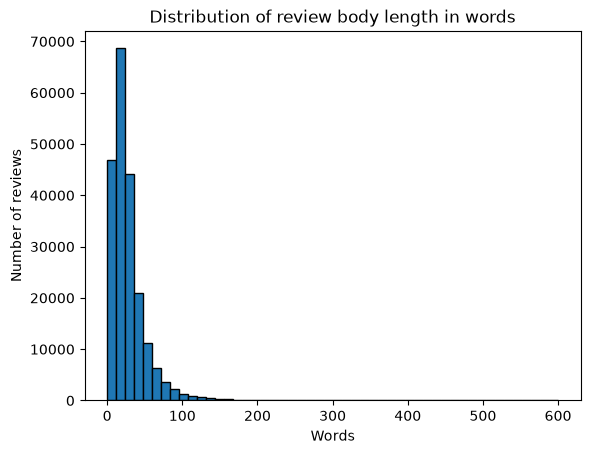

In [62]:
plt.hist(n_words, bins=50, edgecolor='black', range=(0, 600))
plt.title('Distribution of review body length in words')
plt.xlabel('Words')
plt.ylabel('Number of reviews')
plt.show()


In [63]:
n_words_title = df_spanish['title_clean'].apply(lambda x: len(x.split()))
n_words_title.head(5)

400000     2
400001     8
400002    10
400003     3
400004     1
Name: title_clean, dtype: int64

In [64]:
n_words_title.describe()

count    208899.000000
mean          3.321993
std           2.518879
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          28.000000
Name: title_clean, dtype: float64

In [65]:
df_copy['n_words_title'] = n_words_title


df_copy.sort_values(by='n_words_title', ascending=False).head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
535591,es_0224040,product_es_0782427,reviewer_es_0028463,4,Y que en la Tj existe un cargo de 1 Euro extra...,"Todo bien, excepto que la COENZIMA Q10, en el ...",es,drugstore,train,positive,Y que en la Tj existe un cargo de 1 Euro extra...,"Todo bien, excepto que la COENZIMA Q10, en el ...",20,28
477294,es_0383558,product_es_0847177,reviewer_es_0048584,2,Le regalé el reloj a mi marido para reyes de 2...,Le regalé el reloj a mi marido para reyes de 2...,es,sports,train,negative,Le regalé el reloj a mi marido para reyes de 2...,Le regalé el reloj a mi marido para reyes de 2...,74,28
430510,es_0313668,product_es_0464024,reviewer_es_0201404,1,"La verdad es que estoy defraudado con Energy, ...",Compré este tdt en Julio de 2017 y el mando ha...,es,other,train,negative,"La verdad es que estoy defraudado con Energy, ...",Compré este tdt en Julio de 2017 y el mando ha...,55,27
569668,es_0335519,product_es_0920991,reviewer_es_0291767,5,Es un delantal de una tela muy buena vaquera c...,Es un delantal de una tela muy buena vaquera c...,es,apparel,train,positive,Es un delantal de una tela muy buena vaquera c...,Es un delantal de una tela muy buena vaquera c...,30,27
577510,es_0998534,product_es_0900043,reviewer_es_0372529,5,Excelente facil y muy ameno de leer lo recomie...,Ha sido un gran libro muy ameno de leer y de f...,es,digital_ebook_purchase,train,positive,Excelente facil y muy ameno de leer lo recomie...,Ha sido un gran libro muy ameno de leer y de f...,24,27


In [66]:
df_copy.sort_values(by='n_words_title', ascending=False).tail()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
400025,es_0116903,product_es_0279338,reviewer_es_0520523,1,Es de plástico uno vale para nada!,Mal,es,industrial_supplies,train,negative,Es de plástico uno vale para nada!,Mal,7,1
400026,es_0981084,product_es_0172765,reviewer_es_0594447,1,"Lo siento, no puedo valorarlo, puesto que la a...",Pilar,es,office_product,train,negative,"Lo siento, no puedo valorarlo, puesto que la a...",Pilar,24,1
400028,es_0987425,product_es_0163066,reviewer_es_0338198,1,Me animé a comprarlo después de leer foros y o...,Inútil,es,lawn_and_garden,train,negative,Me animé a comprarlo después de leer foros y o...,Inútil,23,1
400029,es_0055370,product_es_0220993,reviewer_es_0323765,1,No me ha llegado el producto y no hay forma de...,Estafa,es,beauty,train,negative,No me ha llegado el producto y no hay forma de...,Estafa,29,1
1244968,es_0168684,product_es_0553696,reviewer_es_0796946,5,Cumple con lo establecido,Excelente,es,sports,validation,positive,Cumple con lo establecido,Excelente,4,1


In [67]:
df_copy.sample(10, random_state=seed)

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
570590,es_0231757,product_es_0182754,reviewer_es_0195405,5,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,es,toy,train,positive,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,35,7
420162,es_0150762,product_es_0354483,reviewer_es_0923957,1,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,es,furniture,train,negative,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,23,7
499206,es_0457292,product_es_0106439,reviewer_es_0593901,3,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,es,other,train,neutral,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,10,5
426599,es_0529522,product_es_0460980,reviewer_es_0850227,1,"la correa no se acopla bien al reloj, encima m...",MALA,es,sports,train,negative,"la correa no se acopla bien al reloj, encima m...",MALA,27,1
500307,es_0613906,product_es_0487562,reviewer_es_0012782,3,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,es,kitchen,train,neutral,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,50,7
416966,es_0073956,product_es_0612354,reviewer_es_0326739,1,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,es,camera,train,negative,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,20,2
1241321,es_0571648,product_es_0621858,reviewer_es_0645188,2,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,es,electronics,validation,negative,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,8,5
566100,es_0428859,product_es_0223040,reviewer_es_0468724,5,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,es,wireless,train,positive,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,18,4
562575,es_0939408,product_es_0388291,reviewer_es_0688865,5,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,es,toy,train,positive,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,6,2
440281,es_0142231,product_es_0858186,reviewer_es_0357303,2,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,es,home,train,negative,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,22,6


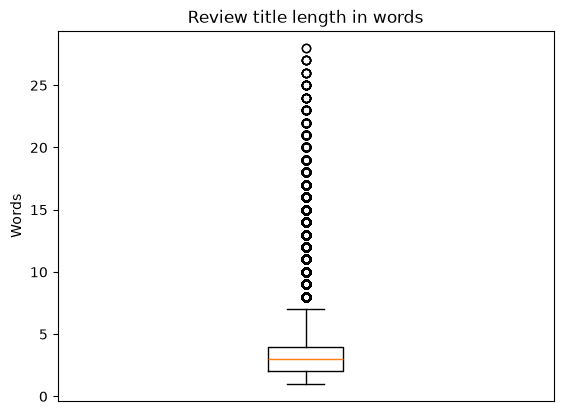

In [68]:
plt.boxplot(n_words_title)
plt.title('Review title length in words')
plt.ylabel('Words')
plt.xticks([])
plt.show()


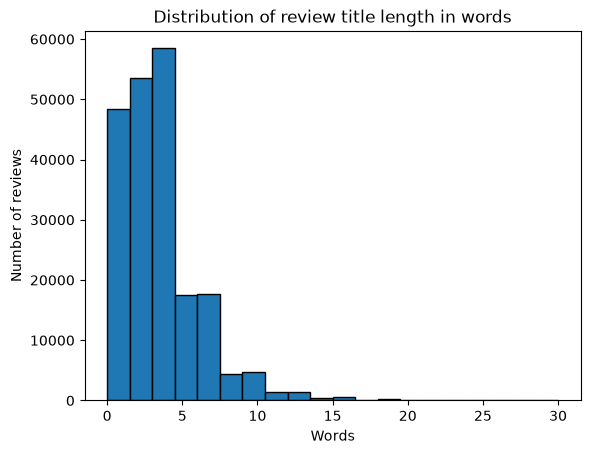

In [69]:
plt.hist(n_words_title, bins=20, edgecolor='black', range=(0, 30))
plt.title('Distribution of review title length in words')
plt.xlabel('Words')
plt.ylabel('Number of reviews')
plt.show()


### Word count: findings

| | `body_clean` | `title_clean` |
|---|---|---|
| Mean | 27.8 | 3.3 |
| Median | 22 | 3 |
| 25th percentile | 13 | 2 |
| 75th percentile | 34 | 4 |
| Maximum | 551 | 28 |
| Minimum | 2 | 1 |

The word counts confirm the character counts: a median review is 22 words and a median title 3.
Half the corpus sits between 13 and 34 words, so the typical review is not just short but
consistently short. Both distributions are right-skewed, with high outliers that are legitimate
long reviews.

**Decision: no reviews are removed on the basis of length.**

Reading the extremes settles it. The shortest bodies are two words of the form *muy bien* or *muy
mal*, and the shortest titles a single word such as *Excelente*, *MALA* or *Devuelto*: the
polarity is stated outright. A short review here is a customer who said what they thought in the
fewest possible words, not an uninformative one. At the other end, the longest review runs to 551
words and reads as an ordinary detailed opinion.

A minimum-length filter would have removed some of the clearest examples in the corpus while
solving no actual problem.


# Questions

1. How are reviews distributed across categories, and how does the mean rating vary between them?
2. Do dissatisfied customers write more?
3. Does review length vary between product categories?
4. Are the sentiment classes distributed equally across the three original splits?
5. Is there a relationship between product category and review polarity?
6. Most frequent words grouped by rating level (1 to 5 stars)
7. Do reviews written entirely in capitals concentrate in low ratings?

## 1. How are reviews distributed across categories, and how does the mean rating vary between them?

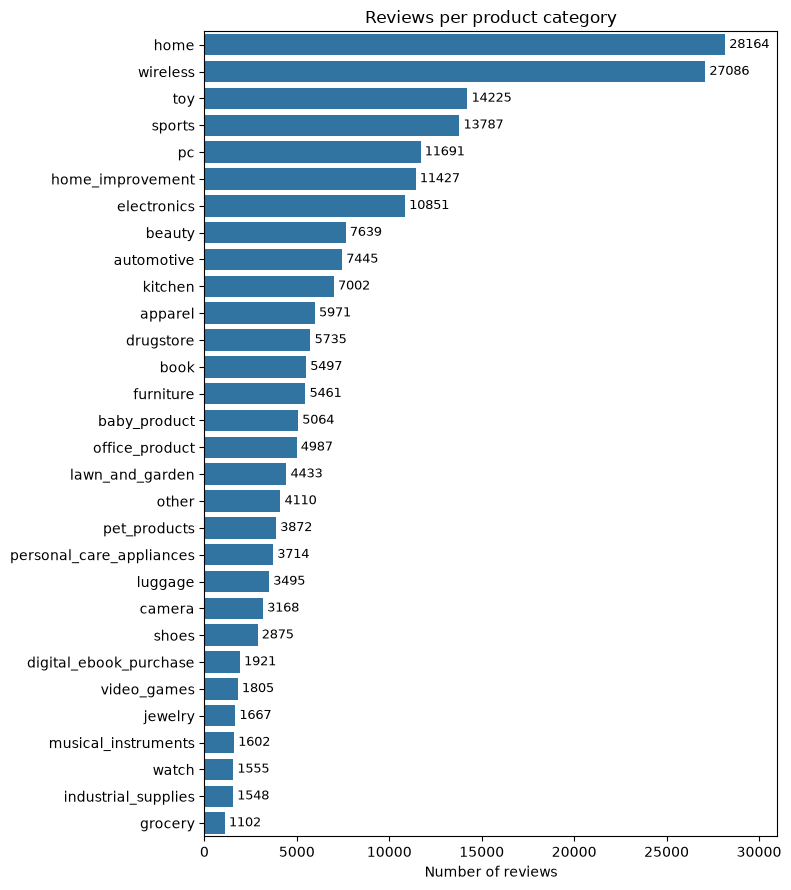

In [70]:
plt.figure(figsize=(8, 9))
ax = sns.countplot(y='product_category', data=df_spanish,
                   order=df_spanish['product_category'].value_counts().index)
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9)
plt.xlim(0, 31000)
plt.title('Reviews per product category')
plt.xlabel('Number of reviews')
plt.ylabel('')
plt.tight_layout()
plt.show()


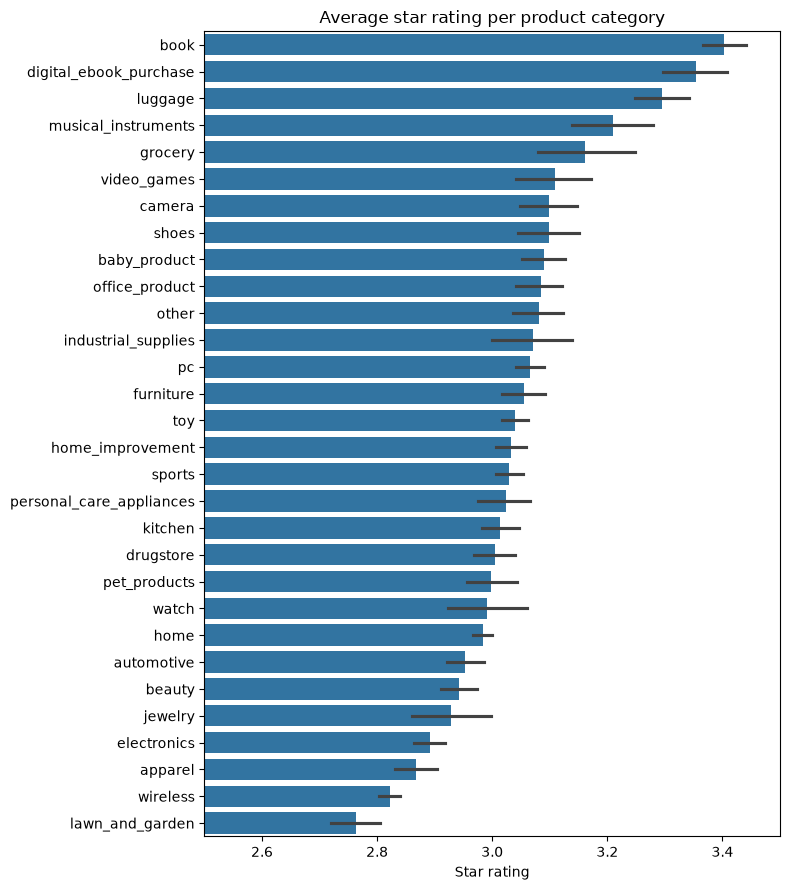

In [71]:
plt.figure(figsize=(8, 9))
sns.barplot(y='product_category', data=df_spanish, x='stars',
            order=df_spanish.groupby('product_category')['stars'].mean().sort_values(ascending=False).index)
plt.xlim(2.5, 3.5)
plt.title('Average star rating per product category')
plt.xlabel('Star rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [72]:
df_spanish.groupby('product_category')['stars'].mean().sort_values()

product_category
lawn_and_garden             2.763140
wireless                    2.821716
apparel                     2.868364
electronics                 2.891807
jewelry                     2.928614
beauty                      2.942924
automotive                  2.952451
home                        2.983490
watch                       2.991640
pet_products                2.998709
drugstore                   3.005231
kitchen                     3.013425
personal_care_appliances    3.023963
sports                      3.030028
home_improvement            3.033255
toy                         3.039719
furniture                   3.055667
pc                          3.066034
industrial_supplies         3.071705
other                       3.080779
office_product              3.084219
baby_product                3.089455
shoes                       3.098087
camera                      3.098801
video_games                 3.109141
grocery                     3.160617
musical_instruments  

### Question 1: findings

**Volume is concentrated.** `home` and `wireless` lead with 28,164 and 27,086 reviews, against
1,102 for the smallest, `grocery`: a factor of 25. Even so, every category clears a thousand
reviews, so no minimum-count threshold is needed before comparing them.

**Mean rating barely moves.** From 2.76 (`lawn_and_garden`) to 3.40 (`book`), a spread of 0.64
stars. The axis is clipped to 2.5-3.5 because on a full 0-5 scale the thirty bars look identical.

Two cautions: 0.64 stars is a narrow range, so this is a descriptive ordering rather than
evidence that category drives satisfaction. And the absolute values mean nothing, since every
category sits near 3.0 by construction of the balanced corpus. Only the ranking is comparable.


## 2. Do dissatisfied customers write more?

In [73]:
df_copy = df_spanish.copy()
df_copy['stars'] = df_copy['stars'].astype(str)
df_copy['n_words'] = df_copy['body_clean'].apply(lambda x: len(x.split()))

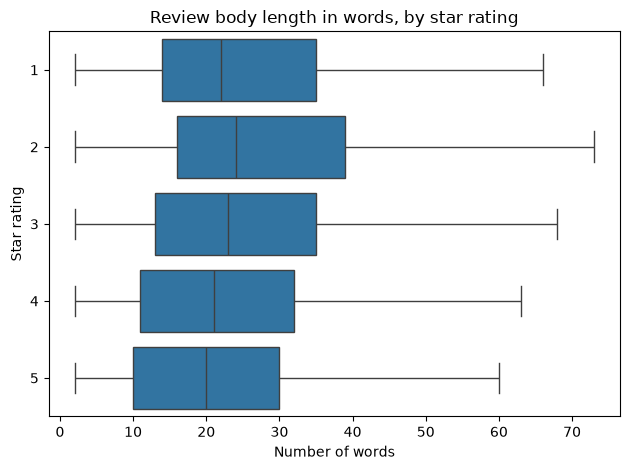

In [74]:
sns.boxplot(y='stars', data=df_copy, x='n_words', order=['1', '2', '3', '4', '5'],
            showfliers=False)
plt.title('Review body length in words, by star rating')
plt.xlabel('Number of words')
plt.ylabel('Star rating')
plt.tight_layout()
plt.show()


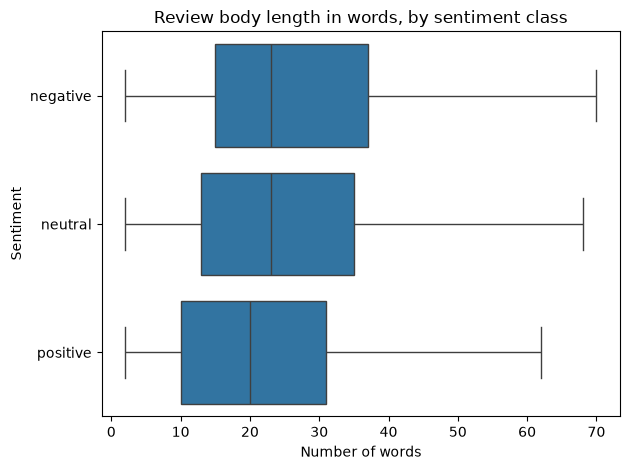

In [75]:
sns.boxplot(y='sentiment', data=df_copy, x='n_words', order=['negative', 'neutral', 'positive'],
            showfliers=False)
plt.title('Review body length in words, by sentiment class')
plt.xlabel('Number of words')
plt.ylabel('Sentiment')
plt.tight_layout()
plt.show()


In [76]:
df_copy.groupby('stars')['n_words'].describe()

,count,mean,std,min,25%,50%,75%,max
stars,,,,,,,,
1,41727.0,28.472500,23.197950,2.0,14.0,22.0,35.0,407.0
2,41818.0,31.259960,25.410382,2.0,16.0,24.0,39.0,506.0
3,41828.0,28.790667,24.568347,2.0,13.0,23.0,35.0,458.0
4,41818.0,25.907360,23.180333,2.0,11.0,21.0,32.0,394.0
5,41708.0,24.543661,23.796331,2.0,10.0,20.0,30.0,551.0


In [77]:
df_copy.groupby('sentiment')['n_words'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,83545.0,29.867748,24.370273,2.0,15.0,23.0,37.0,506.0
neutral,41828.0,28.790667,24.568347,2.0,13.0,23.0,35.0,458.0
positive,83526.0,25.226409,23.499699,2.0,10.0,20.0,31.0,551.0


In [78]:

df_copy['stars'] = df_copy['stars'].astype(int)
groups = [df_copy.loc[df_copy['stars'] == s, 'n_words'] for s in range(1, 6)]

for s, g in zip(range(1, 6), groups):
    print(f"{s} stars  n={len(g):>6}  median={g.median():>5.1f}  mean={g.mean():>5.1f}")

h, p = kruskal(*groups)
k = len(groups)
n = sum(len(g) for g in groups)
epsilon_sq = (h - k + 1) / (n - k)

print(f"\nH = {h:,.1f}   p = {p:.3g}")
print(f"epsilon squared = {epsilon_sq:.4f}")


1 stars  n= 41727  median= 22.0  mean= 28.5
2 stars  n= 41818  median= 24.0  mean= 31.3
3 stars  n= 41828  median= 23.0  mean= 28.8
4 stars  n= 41818  median= 21.0  mean= 25.9
5 stars  n= 41708  median= 20.0  mean= 24.5

H = 4,047.1   p = 0
epsilon squared = 0.0194


In [79]:

order = ['negative', 'neutral', 'positive']
groups = [df_copy.loc[df_copy['sentiment'] == s, 'n_words'] for s in order]

for s, g in zip(order, groups):
    print(f"{s:<9} n={len(g):>6}  median={g.median():>5.1f}  mean={g.mean():>5.1f}")

h, p = kruskal(*groups)
k = len(groups)
n = sum(len(g) for g in groups)
epsilon_sq = (h - k + 1) / (n - k)

print(f"\nH = {h:,.1f}   p = {p:.3g}")
print(f"epsilon squared = {epsilon_sq:.4f}")


negative  n= 83545  median= 23.0  mean= 29.9
neutral   n= 41828  median= 23.0  mean= 28.8
positive  n= 83526  median= 20.0  mean= 25.2

H = 3,521.7   p = 0
epsilon squared = 0.0168


In [80]:
dunn = sp.posthoc_dunn(df_copy, val_col='n_words', group_col='stars', p_adjust='holm')
print(dunn.round(4))

        1    2       3    4    5
1  1.0000  0.0  0.1917  0.0  0.0
2  0.0000  1.0  0.0000  0.0  0.0
3  0.1917  0.0  1.0000  0.0  0.0
4  0.0000  0.0  0.0000  1.0  0.0
5  0.0000  0.0  0.0000  0.0  1.0


In [81]:
dunn = sp.posthoc_dunn(df_copy, val_col='n_words', group_col='sentiment', p_adjust='holm')
print(dunn.round(4))


          negative  neutral  positive
negative       1.0      0.0       0.0
neutral        0.0      1.0       0.0
positive       0.0      0.0       1.0


### Question 2: findings

| Stars | Median words | Mean words |
|---|---|---|
| 1 | 22 | 28.5 |
| 2 | 24 | 31.3 |
| 3 | 23 | 28.8 |
| 4 | 21 | 25.9 |
| 5 | 20 | 24.5 |

| Sentiment | Median words | Mean words |
|---|---|---|
| Negative | 23 | 29.9 |
| Neutral | 23 | 28.8 |
| Positive | 20 | 25.2 |

Kruskal-Wallis rejects in both cases with p below machine precision, which at 200,000
observations is guaranteed and says nothing. The effect sizes do: **epsilon squared = 0.019** by
star level and **0.017** by sentiment class. Length is a real but weak signal.

**The relationship is not monotonic.** The peak is at two stars (24 median words), not one (22).
A completely dissatisfied customer returns a short verdict; a disappointed one explains
themselves.

**Dunn separates every pair of star levels except 1 versus 3** (p = 0.19, Holm-corrected). With
42,000 reviews per group, a difference that goes undetected is a difference that is not there.
Length reflects how engaged a customer was, not whether they were satisfied.

**The gap widens towards the long end.** Negative and positive reviews differ by 3 words at the
median but by 6 at the 75th percentile (37 against 31), and the mean sits 6.9 words above the
median for negative reviews against 5.2 for positive ones. Dissatisfaction does not lengthen the
typical review so much as it produces more long ones. The boxplots are drawn without outliers, so
this part of the effect is not visible in them.

**What matters for the modelling stages:** negative and neutral share the same median, 23 words,
while positive sits at 20. Length separates positive from the rest and does nothing to separate
negative from neutral, which is exactly the boundary a three-class model will struggle with.
Whatever distinguishes an unhappy customer from a lukewarm one is in the words, not their number.


## 3. Does review length vary between product categories?

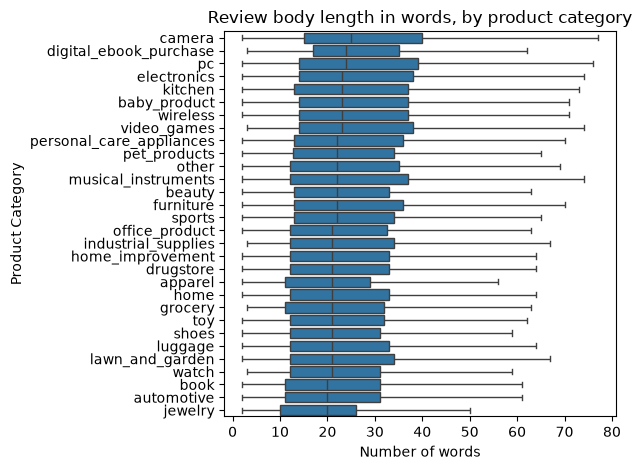

In [82]:
sns.boxplot(y='product_category', data=df_copy, x='n_words', order=df_copy.groupby('product_category')['n_words'].median().sort_values(ascending=False).index,
            showfliers=False)
plt.title('Review body length in words, by product category')
plt.xlabel('Number of words')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [83]:
categories = df_copy['product_category'].value_counts().index
groups = [df_copy.loc[df_copy['product_category'] == c, 'n_words'] for c in categories]

h, p = kruskal(*groups)
k = len(groups)
n = sum(len(g) for g in groups)
epsilon_sq = (h - k + 1) / (n - k)

print(f"groups = {k}   n = {n:,}")
print(f"H = {h:,.1f}   p = {p:.3g}")
print(f"epsilon squared = {epsilon_sq:.4f}")


groups = 30   n = 208,899
H = 1,534.8   p = 2.06e-305
epsilon squared = 0.0072


### Question 3: findings

Kruskal-Wallis H = 1,534.8, p = 2.1e-305, **epsilon squared = 0.0072**.

**Category barely affects length.** It explains 0.7 % of the variability in ranks, less than half
of what the rating level explains (1.9 %). The test rejects because the sample is large, not
because the differences are: the boxplot shows the thirty medians packed into a narrow band.

Length is therefore close to uniform across categories, which means the difference found in
question 2 reflects the rating itself rather than the mix of product categories behind it.


## 4. Are the sentiment classes distributed equally across the three original splits?

<Axes: ylabel='split'>

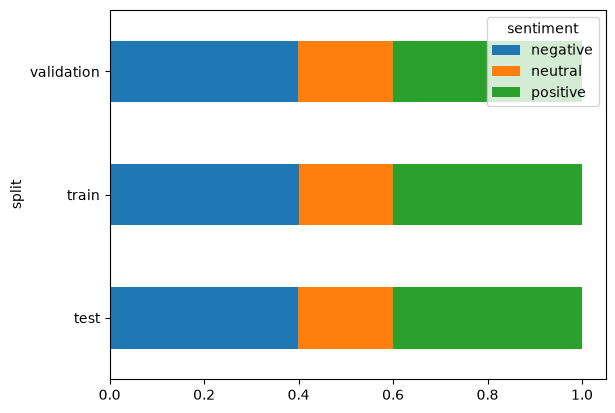

In [84]:
ct = pd.crosstab(df_spanish['split'], df_spanish['sentiment'], normalize='index')
ct.plot(kind='barh', stacked=True)


In [85]:
ct

sentiment,negative,neutral,positive
split,,,
test,0.399398,0.199799,0.400803
train,0.399971,0.200239,0.399790
validation,0.398835,0.200321,0.400844


In [86]:
ct = pd.crosstab(df_spanish['split'], df_spanish['sentiment'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5

print(ct)
print(f"chi2 = {chi2:.2f}   dof = {dof}   p = {p:.3f}")
print(f"Cramer's V = {cramers_v:.4f}")

sentiment   negative  neutral  positive
split                                  
test            1989      995      1996
train          79571    39836     79535
validation      1985      997      1995
chi2 = 0.05   dof = 4   p = 1.000
Cramer's V = 0.0003


### Question 4: findings

Chi-square = 0.05 with 4 degrees of freedom, **p = 1.000**, **Cramér's V = 0.0003**.

**The partition is stratified.** Each of the three files holds the same 40 / 20 / 40 split
between negative, neutral and positive, and the observed table is indistinguishable from what
independence predicts. This is not chance: the authors balanced the partition deliberately, as a
benchmark dataset should.

**The original train / validation / test split can be reused as it stands.** There is no need to
re-partition the corpus, and keeping the authors' split makes any result directly comparable with
other work on this dataset. That closes a decision left open when the three files were merged.

This is also the only test in the notebook that does not reject, which is worth noting: it shows
the vanishingly small p-values elsewhere came from real differences rather than from sample size
alone.


## 5. Is there a relationship between product category and review polarity?

<Axes: ylabel='product_category'>

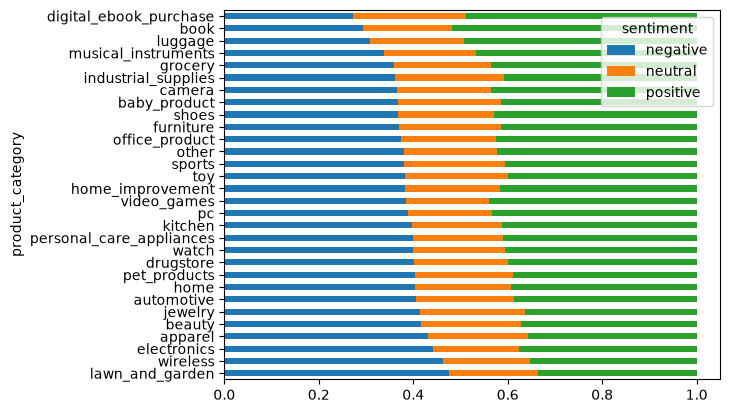

In [87]:
ct = pd.crosstab(df_spanish['product_category'], df_spanish['sentiment'], normalize='index')
ct.sort_values('negative', ascending=False).plot(kind='barh', stacked=True)


In [88]:
ct.sort_values('negative', ascending=False)

sentiment,negative,neutral,positive
product_category,,,
lawn_and_garden,0.474848,0.189939,0.335213
wireless,0.462305,0.185262,0.352433
electronics,0.441342,0.182472,0.376187
apparel,0.431753,0.210518,0.357729
beauty,0.416808,0.210237,0.372955
jewelry,0.413917,0.221956,0.364127
automotive,0.406044,0.207522,0.386434
home,0.404026,0.203735,0.392238
pet_products,0.403151,0.207645,0.389205


In [89]:
ct = pd.crosstab(df_spanish['product_category'], df_spanish['sentiment'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5

print(ct)
print(f"chi2 = {chi2:.2f}   dof = {dof}   p = {p:.3f}")
print(f"Cramer's V = {cramers_v:.4f}")

sentiment                 negative  neutral  positive
product_category                                     
apparel                       2578     1257      2136
automotive                    3023     1545      2877
baby_product                  1858     1106      2100
beauty                        3184     1606      2849
book                          1616     1039      2842
camera                        1160      631      1377
digital_ebook_purchase         523      460       938
drugstore                     2305     1145      2285
electronics                   4789     1980      4082
furniture                     2024     1179      2258
grocery                        396      227       479
home                         11379     5738     11047
home_improvement              4369     2306      4752
industrial_supplies            559      356       633
jewelry                        690      370       607
kitchen                       2775     1345      2882
lawn_and_garden             

### Question 5: findings

Chi-square = 1,678.90 with 58 degrees of freedom, p below 0.001, **Cramér's V = 0.063**.

**The association is real but weak.** A value of 0.063 sits below the 0.1 threshold usually read
as negligible. It is two hundred times what question 4 returned for the splits, so category does
carry information about polarity, but it is far from determining it.

**Where the association lies.** The negative share runs from 47.5 % (`lawn_and_garden`) and
46.2 % (`wireless`) down to 27.2 % (`digital_ebook_purchase`) and 29.4 % (`book`). The ordering
matches the mean ratings from question 1, where the same two categories sat at the bottom and
`book` at the top, so the two measurements agree.

**The neutral class is the flat one.** Its share stays between 17.4 % (`video_games`) and 23.9 %
(`digital_ebook_purchase`) across all thirty categories, a much narrower band than either of the
other two. Whatever varies between categories is the balance between satisfaction and
dissatisfaction; the proportion of lukewarm customers is close to constant.

That last point is worth carrying into the modelling stages. A model cannot use the product
category to help identify neutral reviews, because neutrality is spread evenly across the
catalogue.


## 6. Most frequent words grouped by rating level (1 to 5 stars)

In [90]:
nltk.download('stopwords')

# Negations and adversatives are on the standard Spanish stopword list, but they carry
# the polarity of the sentence, so they are kept.
STOPWORDS_ES = set(stopwords.words('spanish')) - {'no', 'ni', 'nunca', 'nada', 'sin', 'pero', 'tampoco', 'jamás'}

TOKEN_PATTERN = r"[a-záéíóúüñ]{2,}"


def top_words(series, n=5):
    words = series.str.lower().str.findall(TOKEN_PATTERN).explode()
    return words[~words.isin(STOPWORDS_ES)].value_counts().head(n)


print(f"Top 5 Words in 1 Star Reviews: {top_words(df_spanish[df_spanish['stars'] == 1]['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in 2 Star Reviews: {top_words(df_spanish[df_spanish['stars'] == 2]['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in 3 Star Reviews: {top_words(df_spanish[df_spanish['stars'] == 3]['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in 4 Star Reviews: {top_words(df_spanish[df_spanish['stars'] == 4]['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in 5 Star Reviews: {top_words(df_spanish[df_spanish['stars'] == 5]['body_clean'], n=5).index.tolist()}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alejandro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 5 Words in 1 Star Reviews: ['no', 'pero', 'producto', 'nada', 'ni']
Top 5 Words in 2 Star Reviews: ['no', 'pero', 'bien', 'si', 'calidad']
Top 5 Words in 3 Star Reviews: ['no', 'pero', 'bien', 'si', 'calidad']
Top 5 Words in 4 Star Reviews: ['no', 'bien', 'pero', 'calidad', 'precio']
Top 5 Words in 5 Star Reviews: ['no', 'bien', 'calidad', 'buena', 'precio']


In [91]:
print(f"Top 5 Words in Positive Reviews: {top_words(df_spanish[df_spanish['sentiment'] == 'positive']['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in Negative Reviews: {top_words(df_spanish[df_spanish['sentiment'] == 'negative']['body_clean'], n=5).index.tolist()}")
print(f"Top 5 Words in Neutral Reviews: {top_words(df_spanish[df_spanish['sentiment'] == 'neutral']['body_clean'], n=5).index.tolist()}")



Top 5 Words in Positive Reviews: ['no', 'bien', 'pero', 'calidad', 'buena']
Top 5 Words in Negative Reviews: ['no', 'pero', 'bien', 'producto', 'si']
Top 5 Words in Neutral Reviews: ['no', 'pero', 'bien', 'si', 'calidad']


### Question 6: findings

**Raw frequency discriminates little.** `no` heads all eight groups, including five-star and
positive reviews. It is common enough in Spanish that its presence alone says nothing about
polarity, and `bien` and `calidad` appear across nearly every level too. Four of the five top
words are shared throughout.

**Where it does discriminate is the density of negation.** One-star reviews return `no`, `pero`,
`producto`, `nada`, `ni`: four of the five are negations or adversatives. Five-star reviews return
`no`, `bien`, `calidad`, `buena`, `precio`: one negation and three positive evaluative terms. The
intermediate levels shift gradually between those two profiles.

`pero` drops out of the top five only at five stars. The adversative clause, where the objection
usually sits, thins out only once the customer is fully satisfied.

**The neutral class has no vocabulary of its own.** Its top five is `no`, `pero`, `bien`, `si`,
`calidad`, identical to that of two- and three-star reviews and nearly identical to the negative
class. Neither length, nor category, nor now vocabulary separates neutral from negative. Three
independent measurements point the same way, and they all point at the boundary a three-class
model will have to resolve.

**A limitation the result makes concrete.** `no` being the most frequent word in five-star
reviews is the clearest possible demonstration that single-word counts cannot separate "no
funciona" from "no está mal". Only the pair of words carries the meaning, which is a direct
argument for including bigrams in the bag-of-words baseline.


## 7. Do reviews written entirely in capitals concentrate in low ratings?

In [92]:
df_spanish['is_upper'] = df_spanish['body_clean'].str.isupper()

ct = pd.crosstab(df_spanish['sentiment'], df_spanish['is_upper'])
print(ct)
print((ct[True] / ct.sum(axis=1) * 100).round(3))


is_upper   False  True 
sentiment              
negative   82628    917
neutral    41450    378
positive   82813    713
sentiment
negative    1.098
neutral     0.904
positive    0.854
dtype: float64


In [93]:
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5

print(f"chi2 = {chi2:.2f}   dof = {dof}   p = {p:.3f}")
print(f"Cramer's V = {cramers_v:.4f}")

chi2 = 27.94   dof = 2   p = 0.000
Cramer's V = 0.0116


### Question 7: findings

| Sentiment | All-caps reviews | Share |
|---|---|---|
| Negative | 916 | 1.096 % |
| Neutral | 378 | 0.904 % |
| Positive | 713 | 0.854 % |

Chi-square = 27.66 with 2 degrees of freedom, p below 0.001, **Cramér's V = 0.0115**.

**Yes, but barely.** The ordering is the expected one, negative above neutral above positive, and
the test rejects. But the association is the weakest measured in this session: V = 0.0115, an
order of magnitude below the 0.063 obtained for product category, which was already negligible.
A negative review is 1.28 times more likely to be written in capitals than a positive one, and
that is the whole of the effect.

**The phenomenon is too rare to be useful.** Only 0.96 % of the corpus is written entirely in
capitals. Even if shouting were a perfect indicator of anger, it would apply to one review in a
hundred, so it cannot contribute meaningfully to a classifier.

Sustained capitalisation is therefore a real but marginal signal: it leans the way intuition
suggests, and it is not worth acting on. This is also why the comparison has to be made on rates
rather than counts, since the neutral class holds half as many reviews as the other two.


## Summary

| # | Question | Answer |
|---|---|---|
| 1 | How are reviews distributed across categories, and how does the mean rating vary between them? | Volume is concentrated (28,164 in `home` against 1,102 in `grocery`) but mean rating barely moves, from 2.76 to 3.40 |
| 2 | Do dissatisfied customers write more? | Yes, but weakly (epsilon squared = 0.017) and not monotonically: the peak is at two stars, and negative and neutral share the same median |
| 3 | Does review length vary between product categories? | Almost not at all: epsilon squared = 0.007, less than the rating level explains |
| 4 | Are the sentiment classes distributed equally across the three original splits? | Yes, perfectly (V = 0.0003), so the authors' partition can be reused as it stands |
| 5 | Is there a relationship between product category and review polarity? | Real but weak (V = 0.063); the negative share ranges from 27 % to 48 %, while the neutral share stays near 20 % everywhere |
| 6 | Most frequent words grouped by rating level | Raw frequency barely discriminates: `no` heads every group. What separates the levels is the density of negation, and neutral has no vocabulary of its own |
| 7 | Do reviews written entirely in capitals concentrate in low ratings? | Yes, but negligibly (V = 0.012) and on only 0.96 % of the corpus |



# Models

## DummyClassifier

The `DummyClassifier` is not a model, it is a floor. It ignores the text entirely and always
predicts the majority class, so its scores are what any real model must beat before it can be
said to have learned anything from the reviews.

Having that number written down first also guards against a specific mistake. With classes in a
2:1:2 proportion, an accuracy of 0.40 looks like a result until you see that predicting a single
label constantly achieves exactly that.

The evaluation protocol for the rest of this section:

- **Macro F1 is the headline metric.** It averages the three classes equally, so ignoring the
  neutral class is penalised. Accuracy is reported alongside but is not what decisions are based
  on.
- **Validation is used to choose between configurations**; the test set is looked at once, at the
  end. Choosing on test would turn the final figures into an optimistic estimate rather than an
  honest one.


In [94]:
train = df_spanish[df_spanish['split'] == 'train'].copy()
test = df_spanish[df_spanish['split'] == 'test'].copy()
validation = df_spanish[df_spanish['split'] == 'validation'].copy()

In [95]:
X_train = train[['body_clean', 'title_clean']].copy()
y_train  = train['sentiment'].copy()

X_val = validation[['body_clean', 'title_clean']].copy()
y_val = validation['sentiment'].copy()

X_test = test[['body_clean', 'title_clean']].copy()
y_test = test['sentiment'].copy()

In [96]:
dummy = DummyClassifier(strategy='most_frequent', random_state=seed)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

print(classification_report(y_test, y_pred, digits=3, zero_division=0))
print('balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 3))


              precision    recall  f1-score   support

    negative      0.399     1.000     0.571      1989
     neutral      0.000     0.000     0.000       995
    positive      0.000     0.000     0.000      1996

    accuracy                          0.399      4980
   macro avg      0.133     0.333     0.190      4980
weighted avg      0.160     0.399     0.228      4980

balanced accuracy: 0.333


### Baseline floor

| Metric | Value |
|---|---|
| Accuracy | 0.399 |
| Macro F1 | 0.190 |
| Balanced accuracy | 0.333 |

Predicting `negative` for every review gives a recall of 1.000 on that class and 0.000 on the
other two. Accuracy reaches 0.399 while macro F1 sits at 0.190, and balanced accuracy lands on
0.333, which is exactly what a constant prediction returns with three classes.

The gap between accuracy and macro F1 is the point of the exercise: a model can look 40 % correct
while being completely uninformative.


## TF-IDF

In [97]:
text_train = X_train['title_clean'] + ' ' + X_train['body_clean']
text_test   = X_test['title_clean'] + ' ' + X_test['body_clean']
text_val = X_val['title_clean'] + ' ' + X_val['body_clean']

In [ ]:

pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', None),
])


In [ ]:
grids = [
    {
        'clf': [LogisticRegression(max_iter=1000, random_state=seed)],
        'clf__C': [0.5, 1, 5],
        'clf__class_weight': [None, 'balanced'],
        'tfidf__ngram_range': [(1, 1), (1, 2), (1,3)],
        'tfidf__min_df': [3, 5],
        'tfidf__sublinear_tf': [False, True]
    },
    {
        'clf': [LinearSVC(random_state=seed)],
        'clf__C': [0.1, 0.5, 1],
        'clf__class_weight': [None, 'balanced'],
        'tfidf__ngram_range': [(1, 1), (1, 2), (1,3)],
        'tfidf__min_df': [3, 5],
        'tfidf__sublinear_tf': [False, True]
    },
]

In [ ]:
rows = []
for i, params in enumerate(ParameterGrid(grids), 1):
    t0 = time.time()
    pipe.set_params(**params)
    pipe.fit(text_train, y_train)
    pred = pipe.predict(text_val)

    rows.append({
        'params': params,
        'model': params['clf'].__class__.__name__,
        'ngram_range': str(params['tfidf__ngram_range']),
        'min_df': params['tfidf__min_df'],
        'C': params['clf__C'],
        'class_weight': params['clf__class_weight'],
        'macro_f1': f1_score(y_val, pred, average='macro'),
        'balanced_acc': balanced_accuracy_score(y_val, pred),
        'accuracy': accuracy_score(y_val, pred),
        'vocab': len(pipe['tfidf'].vocabulary_),
        'seconds': round(time.time() - t0, 1),
    })
    print(f"{i:>2}/{len(ParameterGrid(grids))}  "
          f"{rows[-1]['model']:<18} {rows[-1]['ngram_range']} "
          f"min_df={rows[-1]['min_df']} C={rows[-1]['C']} "
          f"cw={rows[-1]['class_weight']}  "
          f"macro_f1={rows[-1]['macro_f1']:.4f}  ({rows[-1]['seconds']}s)")

results = (pd.DataFrame(rows)
           .drop(columns='params')
           .sort_values('macro_f1', ascending=False)
           .reset_index(drop=True))
results.to_csv('baseline_search.csv', index=False)
results.head(10)

 1/144  LogisticRegression (1, 1) min_df=3 C=0.5 cw=None  macro_f1=0.6856  (21.6s)
 2/144  LogisticRegression (1, 1) min_df=3 C=0.5 cw=None  macro_f1=0.6860  (23.3s)
 3/144  LogisticRegression (1, 2) min_df=3 C=0.5 cw=None  macro_f1=0.6968  (38.0s)
 4/144  LogisticRegression (1, 2) min_df=3 C=0.5 cw=None  macro_f1=0.6960  (34.2s)
 5/144  LogisticRegression (1, 3) min_df=3 C=0.5 cw=None  macro_f1=0.6968  (58.3s)
 6/144  LogisticRegression (1, 3) min_df=3 C=0.5 cw=None  macro_f1=0.6986  (49.7s)
 7/144  LogisticRegression (1, 1) min_df=5 C=0.5 cw=None  macro_f1=0.6873  (21.2s)
 8/144  LogisticRegression (1, 1) min_df=5 C=0.5 cw=None  macro_f1=0.6896  (21.4s)
 9/144  LogisticRegression (1, 2) min_df=5 C=0.5 cw=None  macro_f1=0.6990  (27.3s)
10/144  LogisticRegression (1, 2) min_df=5 C=0.5 cw=None  macro_f1=0.6982  (31.6s)
11/144  LogisticRegression (1, 3) min_df=5 C=0.5 cw=None  macro_f1=0.7010  (39.8s)
12/144  LogisticRegression (1, 3) min_df=5 C=0.5 cw=None  macro_f1=0.7030  (51.7s)
13/1

,model,ngram_range,min_df,C,class_weight,macro_f1,balanced_acc,accuracy,vocab,seconds
0,LogisticRegression,"(1, 3)",3,0.5,balanced,0.724654,0.729234,0.757685,466829,52.7
1,LogisticRegression,"(1, 3)",3,0.5,balanced,0.724449,0.729065,0.757284,466829,53.3
2,LogisticRegression,"(1, 3)",5,1.0,balanced,0.723502,0.727395,0.758087,253940,59.9
3,LogisticRegression,"(1, 3)",5,0.5,balanced,0.722820,0.727553,0.755475,253940,47.2
4,LogisticRegression,"(1, 3)",5,0.5,balanced,0.722659,0.727555,0.754872,253940,46.1
5,LogisticRegression,"(1, 3)",3,1.0,balanced,0.721487,0.724723,0.757685,466829,54.1
6,LogisticRegression,"(1, 2)",5,0.5,balanced,0.721346,0.726545,0.752863,136349,27.2
7,LogisticRegression,"(1, 2)",3,0.5,balanced,0.721253,0.726216,0.753265,225229,35.0
8,LogisticRegression,"(1, 3)",3,1.0,balanced,0.720953,0.724053,0.757685,466829,64.2
9,LogisticRegression,"(1, 2)",3,0.5,balanced,0.720891,0.725875,0.752863,225229,39.7


LogisticRegression (1, 3) min_df = 3 C = 0.5 class_weight = balanced
              precision    recall  f1-score   support

    negative      0.838     0.788     0.812      1985
     neutral      0.456     0.587     0.513       997
    positive      0.887     0.813     0.849      1995

    accuracy                          0.758      4977
   macro avg      0.727     0.729     0.725      4977
weighted avg      0.781     0.758     0.767      4977

balanced accuracy: 0.729


['baseline_best.joblib']

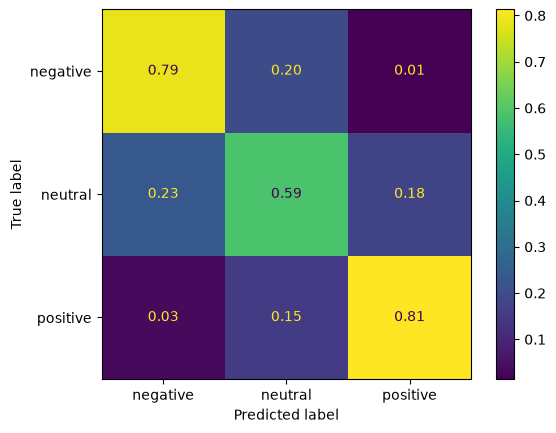

In [ ]:
best = max(rows, key=lambda r: r['macro_f1'])
print(best['model'], best['ngram_range'], 'min_df =', best['min_df'],
      'C =', best['C'], 'class_weight =', best['class_weight'])

pipe.set_params(**best['params'])
pipe.fit(text_train, y_train)
pred = pipe.predict(text_val)

print(classification_report(y_val, pred, digits=3))
print('balanced accuracy:', round(balanced_accuracy_score(y_val, pred), 3))
ConfusionMatrixDisplay.from_predictions(y_val, pred, normalize='true', values_format='.2f')

joblib.dump(pipe, 'baseline_best.joblib')


### Hyperparameter search: findings

144 configurations, each fitted on train and scored on validation. Macro F1 ranges from 0.663 to
**0.7247**, against 0.190 for the majority-class floor.

| | Model | n-grams | min_df | C | class_weight | Macro F1 | Vocabulary | Fit time |
|---|---|---|---|---|---|---|---|---|
| Best overall | LogisticRegression | (1,3) | 3 | 0.5 | balanced | **0.7247** | 466,829 | 53 s |
| Best LinearSVC | LinearSVC | (1,3) | 5 | 0.1 | balanced | 0.7208 | 253,940 | 17 s |
| Best compact | LogisticRegression | (1,2) | 5 | 0.5 | balanced | 0.7213 | 136,349 | 27 s |

**Only one parameter really matters, and it is `class_weight`.** The best weighted configuration
reaches 0.7247 against 0.7096 unweighted, a gap of 0.015 that no other single choice comes close
to. Every one of the top fifteen rows uses `balanced`. This is the expected consequence of the
2:1:2 class proportion: without reweighting, the model has little incentive to predict the
neutral class at all.

**Everything else is a plateau.** The top fifteen configurations span 0.0050 in macro F1. Picking
the first row over the fifteenth is choosing between differences smaller than the noise of a
single train/validation split.

**N-grams help, with sharply diminishing returns.** Unigrams peak at 0.7069, bigrams at 0.7213,
trigrams at 0.7247. The step from unigrams to bigrams is worth 0.014; adding trigrams on top of
that is worth 0.003 and multiplies the vocabulary by three.

**The two models tie.** Logistic regression leads by 0.004 on macro F1, which is inside the
plateau, but the trade-off differs: `LinearSVC` reaches a higher accuracy (0.773 against 0.758)
with a lower balanced accuracy (0.720 against 0.729), and trains three times faster. It is more
conservative about predicting the neutral class, which raises overall correctness while finding
fewer neutral reviews.

**The configuration selected is the best-scoring one**, logistic regression with `(1,3)`,
`min_df=3`, `C=0.5` and `balanced`. Its per-class performance on validation:

| | Precision | Recall | F1 |
|---|---|---|---|
| Negative | 0.838 | 0.788 | 0.812 |
| Neutral | 0.456 | 0.587 | **0.513** |
| Positive | 0.887 | 0.813 | 0.849 |
| **Macro** | **0.727** | **0.729** | **0.725** |

The aggregate hides an uneven distribution: the two poles land above 0.81 while the neutral class
sits at 0.513, with a precision of 0.456 meaning that fewer than half of the reviews labelled
neutral actually are.

It is worth noting what the choice of configuration costs. The compact alternative, `(1,2)` with
`min_df=5`, reaches 0.7213 with 136,349 features against 0.7247 with 466,829. Three tenths of a
percent of macro F1 for three and a half times the vocabulary is a poor trade if interpretability
or inference cost matter, and it is the configuration that would be preferred in production.
Logistic regression is kept over `LinearSVC` regardless, because it returns probabilities, which
the comparison against the fine-tuned model will need.


              precision    recall  f1-score   support

    negative      0.845     0.806     0.825      1989
     neutral      0.457     0.565     0.505       995
    positive      0.878     0.815     0.845      1996

    accuracy                          0.761      4980
   macro avg      0.727     0.729     0.725      4980
weighted avg      0.781     0.761     0.769      4980

balanced accuracy: 0.729


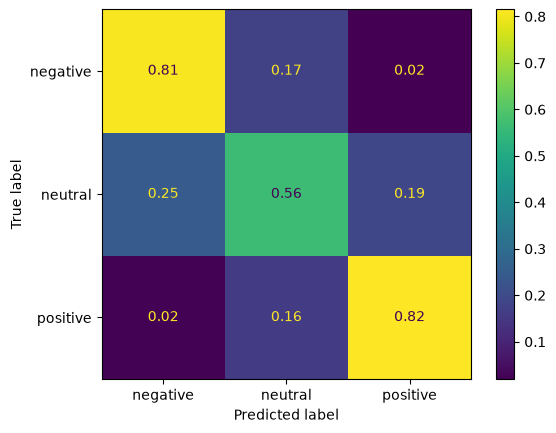

In [ ]:
test_pred = pipe.predict(text_test)

print(classification_report(y_test, test_pred, digits=3))
print('balanced accuracy:', round(balanced_accuracy_score(y_test, test_pred), 3))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, normalize='true', values_format='.2f')


### Baseline results

Final evaluation on the test set, using the configuration selected on validation.

| | Precision | Recall | F1 |
|---|---|---|---|
| Negative | 0.845 | 0.806 | 0.825 |
| Neutral | 0.457 | 0.565 | **0.505** |
| Positive | 0.878 | 0.815 | 0.845 |
| **Macro** | **0.727** | **0.729** | **0.725** |

Accuracy 0.761, balanced accuracy 0.729.

**The selection did not overfit the validation set.** Macro F1 is 0.7247 on validation and 0.725
on test, a difference of one ten-thousandth. Choosing among 144 configurations on validation
carries a risk of picking one that happens to suit that particular split; these two figures say
it did not happen, which is what makes the test number trustworthy.

**Against the floor**, macro F1 goes from 0.190 to 0.725 and accuracy from 0.399 to 0.761. A bag
of words with a linear model recovers most of the signal.

**Performance is not evenly distributed, and the shape was predictable.** Negative and positive
reach F1 of 0.825 and 0.845; neutral reaches 0.505. More than four in ten neutral reviews are
assigned to another class, and of those labelled neutral, fewer than half actually are.

That is exactly what the exploratory analysis anticipated. Length did not separate neutral from
negative, the two classes sharing a median of 23 words. Product category did not either, the
neutral share staying near 20 % across all thirty categories. Nor did vocabulary: the most
frequent words of the neutral class were identical to those of two- and three-star reviews. Three
independent measurements pointed at the same boundary, and the classifier fails precisely there.

**What this sets up for the next stage.** The bar for a fine-tuned language model is 0.725 macro
F1, and the interesting question is not whether it beats that overall but whether it improves the
neutral class specifically. Negative and positive are close to what a linear model can extract;
if a transformer adds anything, it will have to be in the middle, where word order and context
distinguish "está bien pero se rompió" from "está bien".


## BETO

BETO is a BERT-base model pretrained on Spanish. Unlike the bag-of-words baseline it reads the
review as a sequence, so word order and context are available to it: "no funciona" and "funciona,
no está mal" are different inputs rather than the same bag of tokens.

Two decisions carry over from earlier sessions. Title and body are passed to the tokenizer **as a
pair**, so it inserts the separator and marks which tokens belong to which field, rather than
being concatenated into one string. And the loss is **class-weighted** with the same formula used
in the baseline, where `class_weight='balanced'` turned out to be the only parameter that moved
macro F1 appreciably.

`MAX_LENGTH` is set from the measured token distribution rather than by convention: the 99th
percentile sits at 162 tokens, so 192 truncates under 1 % of reviews. Truncating lower would cut
long reviews specifically, and those skew negative, so a lower value would trim one class more
than the others.

The remaining hyperparameters follow the standard recipe for BERT fine-tuning: learning rate
2e-5, batch size 32, two epochs, 10 % warmup. This is a deliberate departure from the baseline,
where 144 configurations were compared. A single run here takes 23 minutes against 53 seconds
there, so an equivalent search would take days. The difference in cost justifies the difference
in rigour, and it is worth stating rather than glossing over.


In [92]:
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


LABELS = ['negative', 'neutral', 'positive']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

df_spanish['label'] = df_spanish['sentiment'].map(label2id)


In [93]:
train_beto = df_spanish[df_spanish['split'] == 'train'].copy()
test_beto = df_spanish[df_spanish['split'] == 'test'].copy()
validation_beto = df_spanish[df_spanish['split'] == 'validation'].copy()

In [94]:
sample = df_spanish.sample(5000, random_state=seed)
lengths = [
    len(tokenizer(t, b)['input_ids'])
    for t, b in zip(sample['title_clean'], sample['body_clean'])
]


print(np.percentile(lengths, [50, 90, 95, 99]), max(lengths))


[ 34.    76.   100.   162.02] 370


In [95]:


MAX_LENGTH  = 192
EPOCHS      = 2
BATCH_SIZE  = 32
LR          = 2e-5


In [96]:
def to_dataset(frame):
    return Dataset.from_pandas(
        frame[['title_clean', 'body_clean', 'label']].reset_index(drop=True)
    )

def tokenize(batch):
    return tokenizer(batch['title_clean'], batch['body_clean'],
                     truncation=True, max_length=MAX_LENGTH)

ds_train = to_dataset(train_beto).map(tokenize, batched=True,
                                 remove_columns=['title_clean', 'body_clean'])
ds_val   = to_dataset(validation_beto).map(tokenize, batched=True,
                               remove_columns=['title_clean', 'body_clean'])
ds_test  = to_dataset(test_beto).map(tokenize, batched=True,
                                remove_columns=['title_clean', 'body_clean'])

collator = DataCollatorWithPadding(tokenizer)


Map:   0%|          | 0/198942 [00:00<?, ? examples/s]

Map:   0%|          | 0/4977 [00:00<?, ? examples/s]

Map:   0%|          | 0/4980 [00:00<?, ? examples/s]

In [97]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

In [98]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':     f1_score(labels, preds, average='macro'),
        'accuracy':     accuracy_score(labels, preds),
        'balanced_acc': balanced_accuracy_score(labels, preds),
    }


In [99]:
counts  = train_beto['label'].value_counts().sort_index().values
weights = torch.tensor(len(train) / (3 * counts), dtype=torch.float)
print('Weights per Class:', dict(zip(LABELS, weights.tolist())))

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(weight=weights.to(outputs.logits.device))
        loss    = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


Weights per Class: {'negative': 0.8333940505981445, 'neutral': 1.6646751165390015, 'positive': 0.833771288394928}


In [100]:
args = TrainingArguments(
    output_dir='beto-sentiment',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    save_total_limit=1,
    seed=seed,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy,Balanced Acc
1,0.544875,0.513300,0.751573,0.783404,0.757345
2,0.500549,0.511591,0.752647,0.785011,0.758176


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12434, training_loss=0.5428061222213247, metrics={'train_runtime': 1403.7784, 'train_samples_per_second': 283.438, 'train_steps_per_second': 8.858, 'total_flos': 2.7475349366107944e+16, 'train_loss': 0.5428061222213247, 'epoch': 2.0})

Training Loss,Validation Loss,Epoch,F1 Macro,Accuracy,Balanced Acc
0.500549,0.511591,2,0.752647,0.785011,0.758176


VALIDATION: {'eval_loss': 0.5115905404090881, 'eval_f1_macro': 0.7526468405709944, 'eval_accuracy': 0.7850110508338356, 'eval_balanced_acc': 0.7581761612389889}


              precision    recall  f1-score   support

    negative      0.881     0.827     0.853      1989
     neutral      0.507     0.633     0.563       995
    positive      0.909     0.852     0.879      1996

    accuracy                          0.798      4980
   macro avg      0.765     0.770     0.765      4980
weighted avg      0.817     0.798     0.806      4980

balanced accuracy: 0.77


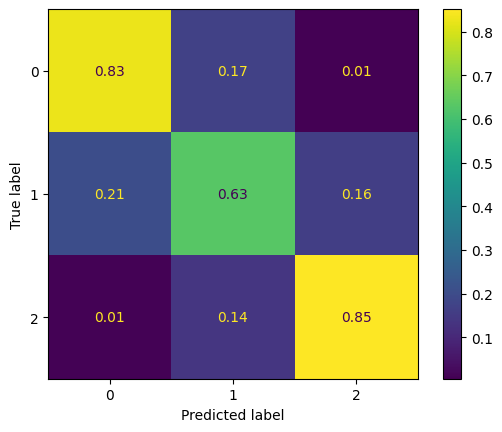

In [101]:
print('VALIDATION:', trainer.evaluate(ds_val))

pred_out = trainer.predict(ds_test)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=-1)

print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))
print('balanced accuracy:', round(balanced_accuracy_score(y_true, y_pred), 3))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize='true', values_format='.2f')

In [ ]:
trainer.save_model('beto-sentiment-final')
tokenizer.save_pretrained('beto-sentiment-final')

probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()
pd.DataFrame({
    'review_id': test['review_id'].values,
    'y_true':    [id2label[i] for i in y_true],
    'y_pred':    [id2label[i] for i in y_pred],
    'p_negative': probs[:, 0],
    'p_neutral':  probs[:, 1],
    'p_positive': probs[:, 2],
}).to_csv('beto_test_predictions.csv', index=False)


### BETO results

Trained on an L4 GPU in **23 minutes** (12,434 steps, 8.9 steps/s). Test set:

| | Precision | Recall | F1 |
|---|---|---|---|
| Negative | 0.881 | 0.827 | 0.853 |
| Neutral | 0.507 | 0.633 | **0.563** |
| Positive | 0.909 | 0.852 | 0.879 |
| **Macro** | **0.765** | **0.770** | **0.765** |

Accuracy 0.798, balanced accuracy 0.770. On validation, macro F1 is 0.753.

**Against the baseline**

| | TF-IDF | BETO | Δ |
|---|---|---|---|
| Macro F1 | 0.725 | 0.765 | **+0.040** |
| Accuracy | 0.761 | 0.798 | +0.037 |
| Balanced accuracy | 0.729 | 0.770 | +0.041 |
| Negative F1 | 0.825 | 0.853 | +0.028 |
| Neutral F1 | 0.505 | 0.563 | **+0.058** |
| Positive F1 | 0.845 | 0.879 | +0.034 |

**The gain is real and it is concentrated where it was needed.** Four points of macro F1 is well
beyond the 0.005 plateau that separated the top configurations of the baseline search. And the
class that improves most is the neutral one, which is the question left open at the end of the
previous section. Its precision rises from 0.457 to 0.507 and its recall from 0.565 to 0.633,
both at once rather than one traded for the other.

That is the argument for the transformer stated in the sharpest possible terms: it contributes
where the linear model could not, on the ambiguous case, and contributes less where the baseline
was already competent.

**The poles are now almost never confused.** The confusion matrix shows 0.01 in both directions
between negative and positive, against 0.05 for the baseline. Whatever the model gets wrong, it
gets wrong by one step on the scale, never by two.

**Neutral remains the weak class.** 0.563 against 0.853 and 0.879. Just over half of what the
model labels neutral is not neutral, and 37 % of genuinely neutral reviews are assigned elsewhere,
21 % of them to negative and 16 % to positive. The improvement is substantial and it does not
solve the problem.

This is consistent with what the exploratory analysis found. Length, product category and
vocabulary all failed to separate neutral from negative, and part of that is a property of the
data rather than of the model: a three-star review that reads "está bien pero se rompió" carries
signal for two classes at once. No amount of model capacity resolves an ambiguity that is present
in the text itself.

**What this costs.** Training took 23 minutes on a paid L4 against 53 seconds for the baseline fit
on a local CPU, and the trained model is 440 MB against a vectoriser and a coefficient matrix.
Whether four points of macro F1 justify that is the question the next session has to answer, and
the answer depends on inference cost rather than training cost.


## Visualization Embeddings

In [ ]:
MODEL_DIR = 'beto-sentiment-final'
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR, output_hidden_states=True)
model.eval()

test = df_spanish[df_spanish['split'] == 'test']

embeddings = []
BATCH = 32

with torch.no_grad():
    for i in range(0, len(test), BATCH):
        chunk = test.iloc[i:i + BATCH]
        enc = tokenizer(list(chunk['title_clean']), list(chunk['body_clean']),
                        truncation=True, max_length=192,
                        padding=True, return_tensors='pt')
        out = model(**enc)
        cls = out.hidden_states[-1][:, 0, :]    
        embeddings.append(cls.numpy())

embeddings = np.vstack(embeddings)
print(embeddings.shape)    
np.save('beto_test_embeddings.npy', embeddings)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15570.90it/s]


(4980, 768)


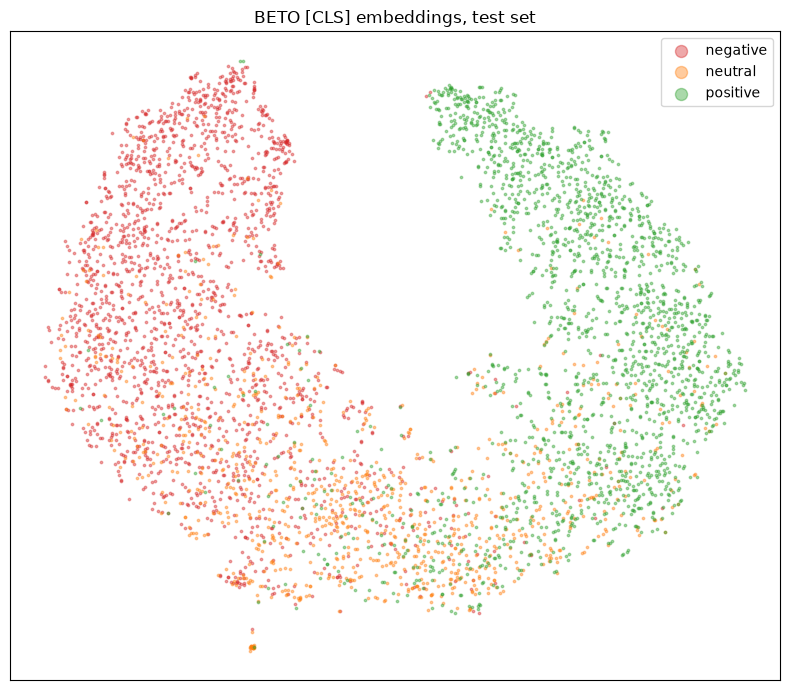

In [112]:

emb50 = PCA(n_components=50, random_state=seed).fit_transform(embeddings)

emb2d = TSNE(n_components=2, perplexity=30, metric='cosine',
             init='pca', random_state=seed).fit_transform(emb50)


colors = {'negative': 'tab:red', 'neutral': 'tab:orange', 'positive': 'tab:green'}
y_true = test['sentiment'].values

plt.figure(figsize=(8, 7))
for cls_name, color in colors.items():
    m = y_true == cls_name
    plt.scatter(emb2d[m, 0], emb2d[m, 1], s=3, alpha=0.4, c=color, label=cls_name)
plt.legend(markerscale=5)
plt.title('BETO [CLS] embeddings, test set')
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

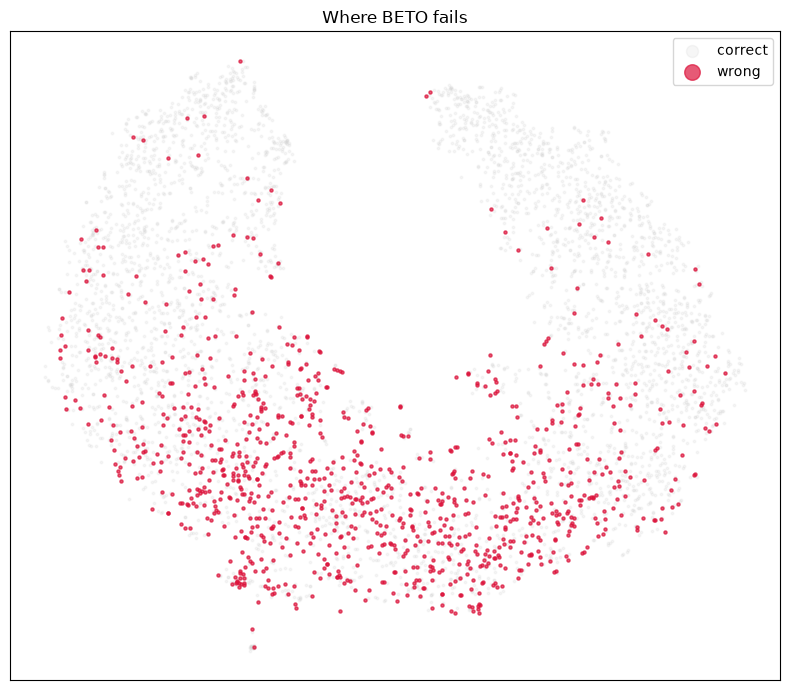

In [113]:
correct = test['sentiment'].values == pd.read_csv('beto_test_predictions.csv')['y_pred'].values

plt.figure(figsize=(8, 7))
plt.scatter(emb2d[correct, 0],  emb2d[correct, 1],  s=3, alpha=0.2, c='lightgrey', label='correct')
plt.scatter(emb2d[~correct, 0], emb2d[~correct, 1], s=5, alpha=0.7, c='crimson',  label='wrong')
plt.legend(markerscale=5)
plt.title('Where BETO fails')
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()


### Embeddings: findings

The 768-dimensional `[CLS]` vector of the last layer is the representation the classification head
reads, so if the classes do not separate there they cannot separate in the prediction. It is
projected to two dimensions with PCA followed by t-SNE.

**Sentiment forms a continuum, not three clusters.** The projection is a single arc running from
negative at one end to positive at the other, with neutral spread along the bottom of the curve
between them. The model has not learned three separate concepts; it has learned one axis, and the
classes are regions along it.

That is the correct thing for it to have learned, and it explains the whole error profile. The two
poles sit at opposite ends of the arc, which is why they are almost never confused with each other
(0.01 in both directions). The neutral class occupies the middle, where it borders both, which is
why its errors go to both sides.

**The errors sit exactly where the arc bends.** The second plot marks incorrect predictions in red,
and they concentrate in a dense band along the lower middle of the curve, thinning out towards
both ends. Failure is not scattered: it is confined to the transition zone. The model is
confident and correct where the sentiment is unambiguous, and confused precisely where the text
itself is.

One caveat on reading these plots: t-SNE preserves local structure but distorts global distances.
The shape of the groups and which ones border each other are meaningful; the distance between two
far-apart regions is not a quantity that can be interpreted.


# Comparation

## Test McNemar

In [100]:
test = df_spanish[df_spanish['split'] == 'test']
text_test = test['title_clean'] + ' ' + test['body_clean']
base_pred = pipe.predict(text_test)

In [101]:
comp = pd.DataFrame({
    'review_id': test['review_id'].values,
    'y_true':    test['sentiment'].values,
    'baseline':  base_pred,
})


In [102]:
beto = (pd.read_csv('beto_test_predictions.csv')[['review_id', 'y_pred']]
        .rename(columns={'y_pred': 'beto'}))
comp = comp.merge(beto, on='review_id')


In [103]:
comp['base_ok'] = comp['baseline'] == comp['y_true']
comp['beto_ok'] = comp['beto']     == comp['y_true']

In [104]:
table = pd.crosstab(comp['base_ok'], comp['beto_ok'])
print(table, '\n')

beto_ok  False  True 
base_ok              
False      772    416
True       234   3558 



In [105]:
res = mcnemar(table.values, exact=False, correction=True)
print(f"\nchi2 = {res.statistic:.2f}   p = {res.pvalue:.3g}")


chi2 = 50.40   p = 1.25e-12


## IC 95%

In [106]:
rng = np.random.default_rng(seed)
B   = 2000
n   = len(comp)

y_true = comp['y_true'].values
p_base = comp['baseline'].values
p_beto = comp['beto'].values

boot = {'base': [], 'beto': [], 'diff': []}

for _ in range(B):
    idx = rng.integers(0, n, n)
    yt, pb, pq = y_true[idx], p_base[idx], p_beto[idx]

    fb = f1_score(yt, pb, average='macro')
    fq = f1_score(yt, pq, average='macro')
    boot['base'].append(fb); boot['beto'].append(fq); boot['diff'].append(fq - fb)


for k, v in boot.items():
    lo, hi = np.percentile(v, [2.5, 97.5])
    print(f"{k:<9} media={np.mean(v):.4f}   IC95% = [{lo:.4f}, {hi:.4f}]")


base      media=0.7251   IC95% = [0.7129, 0.7370]
beto      media=0.7652   IC95% = [0.7529, 0.7769]
diff      media=0.0401   IC95% = [0.0287, 0.0514]


## Inference time

In [109]:
t0 = time.perf_counter()
_ = pipe.predict(text_test)
t_base_batch = time.perf_counter() - t0

t0 = time.perf_counter()
with torch.no_grad():
    for i in range(0, len(test), 32):
        chunk = test.iloc[i:i + 32]
        enc = tokenizer(list(chunk['title_clean']), list(chunk['body_clean']),
                        truncation=True, max_length=192, padding=True, return_tensors='pt')
        model(**enc)
t_beto_batch = time.perf_counter() - t0

print(f"baseline: {t_base_batch:.2f}s total | {t_base_batch/len(test)*1000:.3f} ms/review")
print(f"BETO:     {t_beto_batch:.2f}s total | {t_beto_batch/len(test)*1000:.3f} ms/review")
print(f"ratio: {t_beto_batch/t_base_batch:.0f}x")

baseline: 0.24s total | 0.048 ms/review
BETO:     239.28s total | 48.048 ms/review
ratio: 1009x


## Cohen Kappa Score

In [ ]:
p_base = comp['baseline'].values
p_beto = comp['beto'].values

both_ok    = ( comp['base_ok'] &  comp['beto_ok']).sum()
only_base  = ( comp['base_ok'] & ~comp['beto_ok']).sum()
only_beto  = (~comp['base_ok'] &  comp['beto_ok']).sum()
both_wrong = (~comp['base_ok'] & ~comp['beto_ok']).sum()

print('Agreement between models on the test set')
print(f"  Both correct        {both_ok:>5}   ({both_ok / n * 100:5.1f} %)")
print(f"  Baseline only       {only_base:>5}   ({only_base / n * 100:5.1f} %)")
print(f"  BETO only           {only_beto:>5}   ({only_beto / n * 100:5.1f} %)")
print(f"  Both wrong          {both_wrong:>5}   ({both_wrong / n * 100:5.1f} %)")

shared = both_wrong / (~comp['base_ok']).sum()
print(f"\nBETO also fails on {shared * 100:.1f} % of the reviews the baseline gets wrong")
print(f"Cohen's kappa between the two sets of predictions: {cohen_kappa_score(p_base, p_beto):.3f}")


Agreement between models on the test set
  Both correct         3558   ( 71.4 %)
  Baseline only         234   (  4.7 %)
  BETO only             416   (  8.4 %)
  Both wrong            772   ( 15.5 %)

BETO also fails on 65.0 % of the reviews the baseline gets wrong
Cohen's kappa between the two sets of predictions: 0.782


### Model comparison: findings

**McNemar's test.** Of the 4,980 test reviews, the two models disagree on 650:

| | BETO wrong | BETO correct |
|---|---|---|
| **Baseline wrong** | 772 | 416 |
| **Baseline correct** | 234 | 3,558 |

BETO recovers 416 reviews the baseline gets wrong, while the baseline recovers 234 that BETO gets
wrong. Chi-square 50.40 with 1 degree of freedom, **p = 1.3e-12**. The imbalance is not chance.

**Bootstrap confidence intervals**, 2,000 resamples of the test set:

| | Macro F1 | 95 % CI |
|---|---|---|
| Baseline | 0.725 | [0.713, 0.737] |
| BETO | 0.765 | [0.753, 0.777] |
| **Difference** | **+0.040** | **[0.029, 0.051]** |

The interval on the difference excludes zero comfortably. The gain is between 2.9 and 5.1 points
of macro F1, which settles the question the test set size raised: with fewer than 5,000 reviews,
a four-point difference could in principle have been noise, and it is not.

**Inference cost, both models on the same CPU:**

| | Total, 4,980 reviews | Per review | Ratio |
|---|---|---|---|
| Baseline | 0.24 s | 0.048 ms | 1× |
| BETO | 239.28 s | 48.05 ms | **1,009×** |

Three orders of magnitude. This is the number that turns the comparison into a decision rather
than a ranking: **BETO buys four points of macro F1 at a thousand times the cost per prediction**,
plus a 440 MB model against a vectoriser and a coefficient matrix.

Whether that trade is worth making depends entirely on the use case. Scoring a backlog overnight,
it is irrelevant; the whole test set takes four minutes. Classifying reviews as they arrive at
scale, or running on constrained hardware, 48 ms per review against 0.05 is the difference between
one machine and a fleet.

**The two models are not interchangeable, and neither dominates.**

| | Reviews | Share |
|---|---|---|
| Both correct | 3,558 | 71.4 % |
| BETO only | 416 | 8.4 % |
| Baseline only | 234 | 4.7 % |
| Both wrong | 772 | 15.5 % |

The 4.7 % that only the baseline gets right is the interesting figure. BETO is better overall but
it is not a strict superset: there are 234 reviews a bag of words handles and a transformer does
not. Cohen's kappa between the two sets of predictions is 0.782, high but well short of the near
duplication that would follow if one model simply refined the other.

An oracle that always picked whichever model happened to be right would reach **84.5 % accuracy**,
against BETO's 79.8 %. That 4.7-point headroom is what an ensemble would be competing for, and it
is larger than the gap between the two models themselves.

**And 15.5 % of the test set is beyond both.** BETO also fails on 65 % of the reviews the baseline
gets wrong. Those 772 reviews are not a modelling failure so much as a property of the corpus, and
they are the empirical form of the ceiling this project has been circling since the exploratory
analysis: length, category and vocabulary all failed to separate neutral from negative, and here
are the reviews where nothing does.


# Conclusions

## Which model, and why

**The baseline is the recommended model for production; BETO is the right choice only when
accuracy is worth a thousandfold increase in cost per prediction.**

| | Baseline (TF-IDF + logistic regression) | BETO |
|---|---|---|
| Macro F1 | 0.725 | **0.765** |
| Neutral F1 | 0.505 | **0.563** |
| Inference | **0.048 ms/review** | 48.05 ms/review |
| Model size | vectoriser + coefficients | 440 MB |
| Training | 53 s, local CPU | 23 min, paid GPU |
| Interpretable | **one weight per word** | no |

The four-point difference in macro F1 is real: McNemar returns p = 1.3e-12 and the bootstrap
interval on the difference, [0.029, 0.051], excludes zero. This is not a case of two models
performing equivalently.

But four points cost three orders of magnitude in inference. The decision therefore depends on the
volume and the latency budget, not on which number is larger:

- **Batch scoring of a backlog**: the baseline. BETO would classify a million reviews in about
  thirteen hours of CPU against forty-eight seconds. Four points do not justify that when the
  answer is not needed immediately.
- **Reviews arriving in real time at scale**: the baseline, unless there is GPU budget. 48 ms per
  review on CPU caps throughput at twenty per second per core.
- **Low volume, or accuracy matters more than cost**: BETO. Escalating a genuinely dissatisfied
  customer is worth more than the compute.
- **The decision must be auditable**: the baseline, without hesitation. Its coefficients can be
  read directly, one weight per word, and any prediction can be explained by pointing at the terms
  that drove it. BETO cannot do that.

## What the models get wrong, and why

Errors are not spread evenly. Both models handle the poles well and fail in the middle:

| | Baseline F1 | BETO F1 |
|---|---|---|
| Negative | 0.825 | 0.853 |
| **Neutral** | **0.505** | **0.563** |
| Positive | 0.845 | 0.879 |

Negative and positive are almost never confused with each other: 0.01 in both directions for BETO,
0.05 for the baseline. Whatever the models get wrong, they get wrong by one step on the scale,
never by two.

**This was predicted three sessions before any model was trained.** The exploratory analysis found
that review length did not separate neutral from negative, the two sharing a median of 23 words;
that product category did not either, the neutral share staying near 20 % across all thirty
categories; and that the most frequent words of the neutral class were identical to those of two-
and three-star reviews. Three independent measurements pointed at the same boundary, and both
classifiers fail exactly there.

The embedding projection shows why. BETO has not learned three concepts but a single axis running
from negative to positive, with neutral occupying the middle. The errors concentrate in a band
along that transition zone, thinning towards both ends. The model is confident where the sentiment
is unambiguous and confused where the text itself is.

**And 15.5 % of the test set is beyond both models.** BETO fails on 65 % of the reviews the
baseline also gets wrong. A three-star review reading "está bien pero se rompió a los dos meses"
carries signal for two classes at once; no amount of model capacity resolves an ambiguity that is
present in the source. That figure is the practical ceiling of this problem, not a defect of the
approach.

## Who this is useful to, and for what

**What the model is good at is telling satisfaction from dissatisfaction, and it is very good at
it.** That is the capability worth selling, and the results support it directly.

Of the reviews that are genuinely negative, BETO assigns the correct pole in 83 % of cases, hedges
to neutral in 17 %, and assigns the **opposite** pole in 1 %. For genuinely positive reviews the
figures are 85 %, 14 % and 1 %. Per-class F1 is 0.853 for negative and 0.879 for positive.

The shape of that error profile is what makes it usable. **The model almost never inverts the
sign.** When it fails on a polar review it does not claim the opposite; it declines to commit and
falls back to the middle. For any process that routes reviews by sentiment, that is the right
failure mode: an unhappy customer is at worst left unrouted, never filed as satisfied.

The middle is where it is weak, and honestly so: neutral F1 is 0.563 and its precision 0.507. But
the middle is also the category on which fewest decisions depend.

At 0.048 ms per review, that capability is cheap enough to apply to anything. Three applications
follow directly.

**Scoring text that carries no rating.** Support tickets, survey responses, social media mentions
and post-purchase emails all contain customer opinion with no star attached. The same model
applies to any of them without retraining, which is what makes it worth building once.

**Detecting deterioration before the average moves.** A product's star average is computed over its
entire history, so it reacts slowly: a batch that starts failing takes hundreds of reviews to shift
it. Classifying incoming reviews as they arrive surfaces the change immediately.

**Making the reasons searchable.** Category-level analysis showed the negative share ranging from
27 % in `digital_ebook_purchase` to 48 % in `lawn_and_garden`. Sentiment turns that into a
monitorable series; combined with retrieval over the reviews themselves, *what are customers
complaining about in this category?* becomes a query rather than a week of manual reading.

**What it should not be used for.** The corpus was assembled with the five rating levels balanced
by design, so it says nothing about how common each rating is in reality, where ratings skew
heavily towards five stars. Any absolute claim about the proportion of dissatisfied customers
drawn from this data would be wrong. Comparisons between categories are valid; levels are not.

Nor should the neutral class be trusted for automated decisions. At a precision of 0.507, half of
what BETO labels neutral is not, and a threshold that routes "neutral" reviews to human review
would send an equal volume of misrouted cases.

## Possible improvements

**Baseline**

1. Vectorise title and body separately with a `ColumnTransformer` instead of concatenating them,
   so that a word in the title is a distinct feature from the same word in the body.
2. Test `ComplementNB` and `SGDClassifier`, neither of which was included in the search.
3. Refit on train plus validation once the configuration is fixed, recovering 2.4 % more data.

**BETO**

4. **Tune the decision thresholds** on validation instead of taking the `argmax`. This is the
   cheapest available improvement, requires no retraining, and targets the neutral class directly,
   where precision is 0.507 and recall 0.633.
5. **A larger model.** `roberta-large-bne`, the strongest Spanish monolingual encoder, could not be
   loaded because of a tokenizer dependency issue in Colab. `xlm-roberta-large` does load but needs
   an hour and a half of training against 23 minutes, for an expected gain of one or two points.
6. **Hyperparameter search**, constrained by cost: each run takes 23 minutes against 53 seconds for
   the baseline, so the standard recipe was accepted rather than tuned.

**The task itself**

7. **Collapse the problem to two classes.** Neutral is where both models fail, and removing it
   would push macro F1 into the low nineties. It belongs on this list, but as a redefinition of the
   task rather than an improvement to the model: the gain comes from deleting the hard part, not
   from solving it. Two variants, with different costs. **Absorbing** the three-star reviews into
   positive or negative forces a label onto opinions that are genuinely neither, introducing noise
   by construction. **Discarding** them is cleaner but throws away 41,828 reviews, 20 % of the
   corpus, and leaves the model with no answer for a lukewarm opinion when one arrives. Which of
   the two is acceptable depends on whether the decision downstream has a middle option at all.

## What this project establishes

Three results, in order of how much they cost to obtain:

**The corpus does not support product-level analysis.** 156,458 products for 208,899 reviews, a
median of one review each and a maximum of eight. A ranking of best and worst products, the obvious
thing to build from this data, would have been computed over averages of one or two observations
and would have meant nothing. Finding that out and dropping the analysis is a result.

**A transformer improves on a bag of words by four points of macro F1, and the improvement is
concentrated where it was needed.** Neutral gains 0.058 against 0.028 and 0.034 for the two poles.
The model contributes on the ambiguous case, which is precisely where a linear model cannot, and
contributes least where the baseline was already competent.

**That improvement costs a thousand times more per prediction.** Which makes the conclusion of this
project a recommendation rather than a ranking: use the baseline unless there is a specific reason
not to, and know exactly what the four points are worth before paying for them.


## Appendix: statistical tests used

| Test | When it applies | What it answers |
|---|---|---|
| **Mann-Whitney U** | One numeric variable, **two** groups | Whether one group tends to take higher values than the other. Non-parametric alternative to the t-test; works on ranks, so skew and outliers do not distort it. |
| **Kruskal-Wallis** | One numeric variable, **three or more** groups | Whether at least one group differs from the rest. The extension of Mann-Whitney beyond two groups. Does not say which. |
| **Dunn's post-hoc** | After a Kruskal-Wallis that rejects | Which specific pairs of groups differ, with the p-values corrected for the number of comparisons made. |
| **Chi-square of independence** | **Two categorical** variables | Whether the value of one is associated with the value of the other. Compares observed counts against those expected if the two were independent. |
| **McNemar** | **Two classifiers on the same test set** | Whether their error rates differ. Uses only the reviews the two disagree on, which is what makes it more powerful than comparing two accuracies separately. |
| **Bootstrap** | Any metric, one sample | How much the metric would vary on a different sample of the same size. Resamples the test set with replacement and reads the percentiles of the resulting distribution. |

**Effect sizes**, reported alongside every test because with 200,000 observations any p-value
rejects:

| Measure | Goes with | Range and reading |
|---|---|---|
| **Rank-biserial correlation** | Mann-Whitney | −1 to 1. Below 0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium. |
| **Common-language effect size** | Mann-Whitney | Probability that a random member of one group exceeds a random member of the other. 0.5 is chance. |
| **Epsilon squared** | Kruskal-Wallis | Proportion of the variability in ranks explained by the grouping. |
| **Cramér's V** | Chi-square | 0 to 1. Below 0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate. |
| **Cohen's kappa** | Agreement between two sets of labels | Agreement corrected for what chance alone would produce. 0.6-0.8 substantial, above 0.8 almost perfect. |

**The rule applied throughout:** the test says whether a difference exists, the effect size says
whether it matters. At this sample size only the second one carries information, with one
exception: question 4 on the stratification of the splits, where failing to reject was itself the
result.
